Download the dataset from "https://github.com/jpsety/verilog_benchmark_circuits" and put it under "verilog_benchmark_circuits" folder.

#### Fault Injection

Adding faults  ramdomly.

In [13]:
import os
import shutil
import re
import random
from pathlib import Path

# === CONFIGURATION === #
SRC_DIR = Path("verilog_benchmark_circuits")
FAULT_TYPES = ["stuck_at", "glitch", "bridging"]
OUT_DIRS = {ft: Path(ft) for ft in FAULT_TYPES}
CLEAN_DIR = Path("clean_netlists")
META_LOG = Path("fault_metadata.csv")
random.seed(42)  # reproducibility

# === CLEANUP === #
for d in OUT_DIRS.values():
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

CLEAN_DIR.mkdir(exist_ok=True)
if META_LOG.exists():
    META_LOG.unlink()

# === REGEX to Extract Nets === #
net_decl_re = re.compile(r'\b(?:wire|reg)\s+([^;]+);')

# === Fault Injection Helper === #
def inject_into_module(verilog_text: str, injection: str) -> str:
    parts = verilog_text.rsplit("endmodule", maxsplit=1)
    if len(parts) != 2:
        raise ValueError(f"No endmodule found in {verilog_text[:50]}...")
    return parts[0] + injection + "\nendmodule" + parts[1]

# === MAIN LOOP === #
with open(META_LOG, "w") as metaf:
    metaf.write("filename,fault_type,net1,net2(optional)\n")

    for vfile in sorted(SRC_DIR.glob("*.v")):
        text = vfile.read_text()

        # Save clean copy
        shutil.copy(vfile, CLEAN_DIR / vfile.name)

        # Extract nets
        nets = []
        for m in net_decl_re.finditer(text):
            for tok in re.split(r'[\s,]+', m.group(1).strip()):
                if tok:
                    nets.append(tok)
        if not nets:
            continue

        # Determine fault count: 10% of nets, min 10, max 100
        k = min(100, max(10, int(0.1 * len(nets))))

        ### === STUCK-AT FAULTS === ###
        sa_nets = random.sample(nets, k)
        sa_lines = []
        for net_sa in sa_nets:
            val = random.choice(["1'b0", "1'b1"])
            sa_lines.append(f"  // __INJECTED_FAULT__ type=stuck_at net={net_sa} value={val}")
            sa_lines.append(f"  assign {net_sa} = {val};")
            metaf.write(f"{vfile.name},stuck_at,{net_sa},\n")
        sa_block = "\n".join(sa_lines)
        out_sa = OUT_DIRS["stuck_at"] / f"stuck_at_{vfile.name}"
        out_sa.write_text(inject_into_module(text, sa_block))

        ### === GLITCH FAULTS === ###
        gl_nets = random.sample(nets, k)
        gl_lines = []
        for net_gl in gl_nets:
            delay1 = random.randint(1, 20)
            delay2 = delay1 + random.randint(1, 10)
            gl_lines.append(f"  // __INJECTED_FAULT__ type=glitch net={net_gl} delays=({delay1},{delay2})")
            gl_lines.append(f"  initial begin")
            gl_lines.append(f"    #{delay1} {net_gl} = ~{net_gl};")
            gl_lines.append(f"    #{delay2} {net_gl} = ~{net_gl};")
            gl_lines.append(f"  end")
            metaf.write(f"{vfile.name},glitch,{net_gl},\n")
        gl_block = "\n".join(gl_lines)
        out_gl = OUT_DIRS["glitch"] / f"glitch_{vfile.name}"
        out_gl.write_text(inject_into_module(text, gl_block))

        ### === BRIDGING FAULTS === ###
        br_lines = []
        used_pairs = set()
        for _ in range(k):
            while True:
                n1, n2 = random.sample(nets, 2)
                if n1 != n2 and (n1, n2) not in used_pairs and (n2, n1) not in used_pairs:
                    used_pairs.add((n1, n2))
                    break
            br_lines.append(f"  // __INJECTED_FAULT__ type=bridging nets=({n1},{n2})")
            br_lines.append(f"  assign {n1} = {n2};")
            metaf.write(f"{vfile.name},bridging,{n1},{n2}\n")
        br_block = "\n".join(br_lines)
        out_br = OUT_DIRS["bridging"] / f"bridging_{vfile.name}"
        out_br.write_text(inject_into_module(text, br_block))

print("✅ Fault injection complete. Metadata saved to:", META_LOG)


✅ Fault injection complete. Metadata saved to: fault_metadata.csv


## Creating Netlists Dataset with Varying Number of Faults.

Fault-injection dataset generation. This script generates a reproducible number-of-faults sweep dataset from clean ISCAS85/EPFL Verilog netlists. For each source netlist, it extracts valid candidate nets from wire, reg, logic, tri, wand, and wor declarations, then creates faulted versions for three configurable fault-count ranges: 100-500, 500-1000, and 1000-2000. Within each range, a requested fault count k is selected according to K_SELECTION_MODE, and the same k is used for all three fault types to keep the comparison controlled. The injected faults follow the experiment description: stuck-at faults force selected nets to logic 0 or 1, glitch faults toggle selected nets twice at random delays, and bridging faults connect unique unordered net pairs using an assignment. This corresponds to the papers higher-fault-ratio experiment, where the injection range is extended to 100500, 5001000, and 10002000 faults while keeping the rest of the setup unchanged.

Output organization and reviewer-facing statistics. The script saves all generated files under fault_injection_fig_faultsweep/, with clean netlists stored separately in clean_netlists/ and faulted netlists organized by fault-count range and fault type, for example 100-500/stuck_at/, 100-500/glitch/, and 100-500/bridging/. It also writes detailed metadata files that make the injection process auditable: fault_metadata_detailed.csv records every injected fault, while fault_injection_summary.csv and range_summary.csv summarize requested fault counts, actually inserted counts, candidate-net availability, feasible bridging-pair counts, and whether any netlist was capped due to insufficient feasible fault sites. These summaries are useful for responding to reviewers because they explicitly document how many faults were requested, how many were actually inserted, and why the effective count may be lower for smaller circuits.

In [1]:
# ============================================================
# Fig. (Number of faults sweep)  Fault Injection Dataset Generator
# for ISCAS85 / EPFL Verilog Netlists
#
# Reproduces the varying-fault-count experiment described for Fig. (Number of faults sweep):
#   ranges = 100-500, 500-1000, 1000-2000 injected faults
#
# For each clean Verilog file and each fault-count range:
#   1. stuck_at:  k selected nets assigned permanently to 0/1
#   2. glitch:    k selected nets toggled twice at random delays
#   3. bridging: k unique unordered net pairs shorted by assign n1 = n2
#
# Output structure:
#   fault_injection_fig_faultsweep/
#       clean_netlists/
#       100-500/
#           stuck_at/
#           glitch/
#           bridging/
#       500-1000/
#           stuck_at/
#           glitch/
#           bridging/
#       1000-2000/
#           stuck_at/
#           glitch/
#           bridging/
#       fault_metadata_detailed.csv
#       fault_injection_summary.csv
#       range_summary.csv
#       README_fault_injection_fig_faultsweep.txt
#
# Notes for reviewer-facing statistics:
#   - requested_k is the random integer selected inside the range.
#   - effective_k is the number actually inserted after feasibility caps.
#   - stuck_at/glitch require unique selected nets, so effective_k <= #candidate_nets.
#   - bridging requires unique unordered pairs, so effective_k <= #feasible_pairs.
#   - summary CSVs explicitly report all caps.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import csv
import hashlib
import math
import random
import re
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import pandas as pd


# -------------------------
# Input/output paths
# -------------------------
SRC_DIR = Path("verilog_benchmark_circuits")
OUT_ROOT = Path("fault_injection_fig_faultsweep")

CLEAN_DIR_NAME = "clean_netlists"

FAULT_TYPES = ["stuck_at", "glitch", "bridging"]

# Fig. (Number of faults sweep) ranges from the paper.
FAULT_RANGES = [
    (100, 500),
    (500, 1000),
    (1000, 2000),
]

# How k is chosen inside each range.
#   "uniform": random integer in [low, high]
#   "midpoint": floor((low + high) / 2)
#   "upper": high
#   "lower": low
K_SELECTION_MODE = "uniform"

# If True, deletes OUT_ROOT before regenerating.
OVERWRITE_OUTPUT = True

# Reproducibility.
GLOBAL_SEED = 42

# Keep close to paper/code style:
#   stuck_at: assign net = value;
#   bridging: assign net1 = net2;
#
# For glitch:
#   "paper_toggle" emits:
#       initial begin
#         #d1 net = ~net;
#         #(d2-d1) net = ~net;
#       end
#   "force_release" is simulator-friendlier for wire nets:
#       initial begin
#         #d1 force net = ~net;
#         #(d2-d1) force net = ~net;
#         #1 release net;
#       end
GLITCH_STYLE = "paper_toggle"      # choices: "paper_toggle", "force_release"

# Candidate extraction:
#   The original code used wire/reg declarations only.
#   This refined parser also supports logic/tri/wand/wor.
DECLARATION_KINDS = ("wire", "reg", "logic", "tri", "wand", "wor")

# Bridging with same-width nets avoids obvious vector-width mismatch.
ENFORCE_BRIDGE_SAME_WIDTH = True

# If a netlist has fewer feasible sites than requested k, cap effective k.
CAP_TO_FEASIBLE = True

# Delay settings for glitch faults.
GLITCH_DELAY_MIN = 1
GLITCH_DELAY_MAX = 20
GLITCH_SECOND_DELAY_EXTRA_MIN = 1
GLITCH_SECOND_DELAY_EXTRA_MAX = 10


# ============================================================
# 2. Utility functions
# ============================================================

@dataclass(frozen=True)
class NetCandidate:
    name: str
    width: Optional[int]
    kind: str


def stable_rng(*parts) -> random.Random:
    """
    Create a stable per-file/per-range/per-fault RNG independent of Python's
    randomized hash seed.
    """
    key = "|".join([str(GLOBAL_SEED)] + [str(p) for p in parts])
    digest = hashlib.sha256(key.encode("utf-8")).hexdigest()
    seed_int = int(digest[:16], 16)
    return random.Random(seed_int)


def strip_verilog_comments(text: str) -> str:
    """
    Remove Verilog // and /* */ comments for declaration parsing.
    The original text is not modified for output.
    """
    text = re.sub(r"/\*.*?\*/", "", text, flags=re.DOTALL)
    text = re.sub(r"//.*?$", "", text, flags=re.MULTILINE)
    return text


def parse_decl_width(range_text: Optional[str]) -> Optional[int]:
    """
    Parse simple packed ranges like [7:0].
    Returns None for parameterized or unparseable ranges.
    """
    if not range_text:
        return 1

    m = re.search(r"\[\s*(-?\d+)\s*:\s*(-?\d+)\s*\]", range_text)
    if not m:
        return None

    msb = int(m.group(1))
    lsb = int(m.group(2))
    return abs(msb - lsb) + 1


VALID_IDENTIFIER_RE = re.compile(r"^[A-Za-z_][A-Za-z0-9_$]*$")

VERILOG_KEYWORDS = {
    "wire", "reg", "logic", "tri", "wand", "wor",
    "signed", "unsigned", "input", "output", "inout",
    "assign", "module", "endmodule",
}


def extract_net_candidates(verilog_text: str) -> List[NetCandidate]:
    """
    Extract candidate nets from declarations.

    Handles declarations such as:
        wire a, b, c;
        wire [7:0] bus1, bus2;
        reg signed [3:0] r;
        logic foo;

    It intentionally ignores module port names unless separately declared as
    wire/reg/logic/etc., matching the user's original code more closely.
    """
    parse_text = strip_verilog_comments(verilog_text)

    kind_alt = "|".join(DECLARATION_KINDS)
    decl_re = re.compile(
        rf"\b(?P<kind>{kind_alt})\b\s+(?P<rest>[^;]+);",
        flags=re.IGNORECASE | re.MULTILINE | re.DOTALL,
    )

    candidates_by_name: Dict[str, NetCandidate] = {}

    for m in decl_re.finditer(parse_text):
        kind = m.group("kind").lower()
        rest = " ".join(m.group("rest").replace("\n", " ").split())

        # Remove optional signed/unsigned before packed range.
        rest = re.sub(r"^\b(?:signed|unsigned)\b\s+", "", rest, flags=re.IGNORECASE)

        range_match = re.match(r"(?P<range>\[[^\]]+\])\s*(?P<body>.*)$", rest)
        if range_match:
            width = parse_decl_width(range_match.group("range"))
            body = range_match.group("body")
        else:
            width = 1
            body = rest

        # Split declaration body on commas. This is sufficient for ordinary
        # gate-level netlists and the user's original benchmark style.
        for raw_item in body.split(","):
            item = raw_item.strip()

            if not item:
                continue

            # Remove initialization and unpacked dimensions.
            item = item.split("=")[0].strip()
            item = re.sub(r"\[[^\]]+\]", "", item).strip()
            item = re.sub(r"\b(?:signed|unsigned)\b", "", item, flags=re.IGNORECASE).strip()

            if not item:
                continue

            # If extra tokens remain, use the last token as identifier.
            name = item.split()[-1].strip()

            if not name:
                continue

            if name.lower() in VERILOG_KEYWORDS:
                continue

            # Skip escaped or exotic names here for safe generated Verilog.
            # Extend this block if your benchmarks use escaped identifiers.
            if not VALID_IDENTIFIER_RE.match(name):
                continue

            if name not in candidates_by_name:
                candidates_by_name[name] = NetCandidate(
                    name=name,
                    width=width,
                    kind=kind,
                )

    return sorted(candidates_by_name.values(), key=lambda x: x.name)


def choose_requested_k(low: int, high: int, rng: random.Random) -> int:
    if K_SELECTION_MODE == "uniform":
        return rng.randint(low, high)

    if K_SELECTION_MODE == "midpoint":
        return int((low + high) // 2)

    if K_SELECTION_MODE == "upper":
        return int(high)

    if K_SELECTION_MODE == "lower":
        return int(low)

    raise ValueError(
        "K_SELECTION_MODE must be one of: uniform, midpoint, upper, lower"
    )


def range_label(low: int, high: int) -> str:
    return f"{low}-{high}"


def verilog_constant_for_width(width: Optional[int], bit_value: int) -> str:
    """
    Generate 0/1 literal for scalar or vector nets.
    """
    if width is None or width <= 1:
        return "1'b1" if bit_value == 1 else "1'b0"

    return f"{{{width}{{1'b{bit_value}}}}}"


def inject_into_last_module(verilog_text: str, injection: str, source_name: str) -> str:
    """
    Append fault logic immediately before the final endmodule.
    """
    if not injection.strip():
        return verilog_text

    parts = verilog_text.rsplit("endmodule", maxsplit=1)

    if len(parts) != 2:
        raise ValueError(f"No endmodule found in {source_name}")

    return parts[0].rstrip() + "\n\n" + injection.rstrip() + "\nendmodule" + parts[1]


def sample_unique_nets(
    candidates: List[NetCandidate],
    requested_k: int,
    rng: random.Random,
) -> List[NetCandidate]:
    if not candidates:
        return []

    effective_k = min(requested_k, len(candidates)) if CAP_TO_FEASIBLE else requested_k

    if effective_k > len(candidates):
        raise ValueError(
            f"Requested {requested_k} unique nets but only {len(candidates)} candidates exist."
        )

    return rng.sample(candidates, effective_k)


def feasible_bridge_pair_count(candidates: List[NetCandidate]) -> int:
    if len(candidates) < 2:
        return 0

    if not ENFORCE_BRIDGE_SAME_WIDTH:
        return len(candidates) * (len(candidates) - 1) // 2

    width_groups: Dict[Optional[int], int] = {}
    for c in candidates:
        width_groups[c.width] = width_groups.get(c.width, 0) + 1

    return sum(n * (n - 1) // 2 for n in width_groups.values() if n >= 2)


def enumerate_bridge_pairs(candidates: List[NetCandidate]) -> List[Tuple[NetCandidate, NetCandidate]]:
    pairs = []

    if ENFORCE_BRIDGE_SAME_WIDTH:
        groups: Dict[Optional[int], List[NetCandidate]] = {}

        for c in candidates:
            groups.setdefault(c.width, []).append(c)

        for group in groups.values():
            group = sorted(group, key=lambda x: x.name)
            for i in range(len(group)):
                for j in range(i + 1, len(group)):
                    pairs.append((group[i], group[j]))
    else:
        candidates = sorted(candidates, key=lambda x: x.name)
        for i in range(len(candidates)):
            for j in range(i + 1, len(candidates)):
                pairs.append((candidates[i], candidates[j]))

    return pairs


def sample_unique_bridge_pairs(
    candidates: List[NetCandidate],
    requested_k: int,
    rng: random.Random,
) -> List[Tuple[NetCandidate, NetCandidate]]:
    feasible = feasible_bridge_pair_count(candidates)

    if feasible == 0:
        return []

    effective_k = min(requested_k, feasible) if CAP_TO_FEASIBLE else requested_k

    if effective_k > feasible:
        raise ValueError(
            f"Requested {requested_k} unique bridge pairs but only {feasible} feasible pairs exist."
        )

    # If feasible is modest, enumerate and sample directly.
    if feasible <= max(100000, effective_k * 20):
        all_pairs = enumerate_bridge_pairs(candidates)
        return rng.sample(all_pairs, effective_k)

    # Otherwise use rejection sampling by width groups.
    if ENFORCE_BRIDGE_SAME_WIDTH:
        groups: List[List[NetCandidate]] = []
        weights: List[int] = []

        by_width: Dict[Optional[int], List[NetCandidate]] = {}
        for c in candidates:
            by_width.setdefault(c.width, []).append(c)

        for group in by_width.values():
            if len(group) >= 2:
                groups.append(group)
                weights.append(len(group) * (len(group) - 1) // 2)
    else:
        groups = [candidates]
        weights = [len(candidates) * (len(candidates) - 1) // 2]

    selected_keys = set()
    pairs = []
    max_attempts = max(1000, effective_k * 100)

    attempts = 0
    while len(pairs) < effective_k and attempts < max_attempts:
        attempts += 1

        group = rng.choices(groups, weights=weights, k=1)[0]
        a, b = rng.sample(group, 2)

        key = tuple(sorted([a.name, b.name]))

        if key in selected_keys:
            continue

        selected_keys.add(key)

        # Randomize direction of short assignment.
        if rng.random() < 0.5:
            pairs.append((a, b))
        else:
            pairs.append((b, a))

    if len(pairs) < effective_k:
        # Safe fallback if rejection sampling struggled.
        all_pairs = enumerate_bridge_pairs(candidates)
        remaining = [
            p for p in all_pairs
            if tuple(sorted([p[0].name, p[1].name])) not in selected_keys
        ]
        need = effective_k - len(pairs)
        pairs.extend(rng.sample(remaining, need))

    return pairs


# ============================================================
# 3. Fault-block builders
# ============================================================

def build_stuck_at_block(
    selected_nets: List[NetCandidate],
    rng: random.Random,
    low: int,
    high: int,
    source_file: str,
    requested_k: int,
    detailed_writer: csv.DictWriter,
    output_file: Path,
):
    label = range_label(low, high)

    lines = []
    rows_written = 0

    for fault_id, net in enumerate(selected_nets, start=1):
        bit_value = rng.choice([0, 1])
        literal = verilog_constant_for_width(net.width, bit_value)

        lines.append(
            f"  // __INJECTED_FAULT__ range={label} "
            f"type=stuck_at id={fault_id} net={net.name} value={literal}"
        )
        lines.append(f"  assign {net.name} = {literal};")

        detailed_writer.writerow({
            "range_label": label,
            "range_min": low,
            "range_max": high,
            "source_file": source_file,
            "output_file": str(output_file),
            "fault_type": "stuck_at",
            "requested_k": requested_k,
            "effective_k": len(selected_nets),
            "fault_index": fault_id,
            "net1": net.name,
            "net2": "",
            "value": literal,
            "delay1": "",
            "delay2": "",
            "width1": net.width if net.width is not None else "unknown",
            "width2": "",
            "candidate_nets": "",
            "feasible_fault_sites": "",
            "capped": int(len(selected_nets) < requested_k),
        })
        rows_written += 1

    return "\n".join(lines), rows_written


def build_glitch_block(
    selected_nets: List[NetCandidate],
    rng: random.Random,
    low: int,
    high: int,
    source_file: str,
    requested_k: int,
    detailed_writer: csv.DictWriter,
    output_file: Path,
):
    label = range_label(low, high)

    lines = []
    rows_written = 0

    for fault_id, net in enumerate(selected_nets, start=1):
        delay1 = rng.randint(GLITCH_DELAY_MIN, GLITCH_DELAY_MAX)
        delay2 = delay1 + rng.randint(GLITCH_SECOND_DELAY_EXTRA_MIN, GLITCH_SECOND_DELAY_EXTRA_MAX)
        delta_delay = delay2 - delay1

        lines.append(
            f"  // __INJECTED_FAULT__ range={label} "
            f"type=glitch id={fault_id} net={net.name} delays=({delay1},{delay2})"
        )
        lines.append("  initial begin")

        if GLITCH_STYLE == "paper_toggle":
            # Refined absolute-delay equivalent:
            # first event at delay1, second event at delay2.
            lines.append(f"    #{delay1} {net.name} = ~{net.name};")
            lines.append(f"    #{delta_delay} {net.name} = ~{net.name};")
        elif GLITCH_STYLE == "force_release":
            lines.append(f"    #{delay1} force {net.name} = ~{net.name};")
            lines.append(f"    #{delta_delay} force {net.name} = ~{net.name};")
            lines.append(f"    #1 release {net.name};")
        else:
            raise ValueError("GLITCH_STYLE must be 'paper_toggle' or 'force_release'.")

        lines.append("  end")

        detailed_writer.writerow({
            "range_label": label,
            "range_min": low,
            "range_max": high,
            "source_file": source_file,
            "output_file": str(output_file),
            "fault_type": "glitch",
            "requested_k": requested_k,
            "effective_k": len(selected_nets),
            "fault_index": fault_id,
            "net1": net.name,
            "net2": "",
            "value": "",
            "delay1": delay1,
            "delay2": delay2,
            "width1": net.width if net.width is not None else "unknown",
            "width2": "",
            "candidate_nets": "",
            "feasible_fault_sites": "",
            "capped": int(len(selected_nets) < requested_k),
        })
        rows_written += 1

    return "\n".join(lines), rows_written


def build_bridging_block(
    selected_pairs: List[Tuple[NetCandidate, NetCandidate]],
    low: int,
    high: int,
    source_file: str,
    requested_k: int,
    detailed_writer: csv.DictWriter,
    output_file: Path,
):
    label = range_label(low, high)

    lines = []
    rows_written = 0

    for fault_id, (n1, n2) in enumerate(selected_pairs, start=1):
        lines.append(
            f"  // __INJECTED_FAULT__ range={label} "
            f"type=bridging id={fault_id} nets=({n1.name},{n2.name})"
        )
        lines.append(f"  assign {n1.name} = {n2.name};")

        detailed_writer.writerow({
            "range_label": label,
            "range_min": low,
            "range_max": high,
            "source_file": source_file,
            "output_file": str(output_file),
            "fault_type": "bridging",
            "requested_k": requested_k,
            "effective_k": len(selected_pairs),
            "fault_index": fault_id,
            "net1": n1.name,
            "net2": n2.name,
            "value": "",
            "delay1": "",
            "delay2": "",
            "width1": n1.width if n1.width is not None else "unknown",
            "width2": n2.width if n2.width is not None else "unknown",
            "candidate_nets": "",
            "feasible_fault_sites": "",
            "capped": int(len(selected_pairs) < requested_k),
        })
        rows_written += 1

    return "\n".join(lines), rows_written


# ============================================================
# 4. Output setup
# ============================================================

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Source directory not found: {SRC_DIR}")

if OUT_ROOT.exists():
    if OVERWRITE_OUTPUT:
        shutil.rmtree(OUT_ROOT)
    else:
        raise FileExistsError(
            f"{OUT_ROOT} already exists. Set OVERWRITE_OUTPUT=True to regenerate."
        )

OUT_ROOT.mkdir(parents=True, exist_ok=True)

CLEAN_DIR = OUT_ROOT / CLEAN_DIR_NAME
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

for low, high in FAULT_RANGES:
    label = range_label(low, high)
    for fault_type in FAULT_TYPES:
        (OUT_ROOT / label / fault_type).mkdir(parents=True, exist_ok=True)

metadata_path = OUT_ROOT / "fault_metadata_detailed.csv"
summary_path = OUT_ROOT / "fault_injection_summary.csv"
range_summary_path = OUT_ROOT / "range_summary.csv"
readme_path = OUT_ROOT / "README_fault_injection_fig_faultsweep.txt"


metadata_fields = [
    "range_label",
    "range_min",
    "range_max",
    "source_file",
    "output_file",
    "fault_type",
    "requested_k",
    "effective_k",
    "fault_index",
    "net1",
    "net2",
    "value",
    "delay1",
    "delay2",
    "width1",
    "width2",
    "candidate_nets",
    "feasible_fault_sites",
    "capped",
]

summary_fields = [
    "range_label",
    "range_min",
    "range_max",
    "source_file",
    "fault_type",
    "requested_k",
    "effective_k",
    "candidate_nets",
    "feasible_fault_sites",
    "capped",
    "output_file",
]


# ============================================================
# 5. Main generation loop
# ============================================================

summary_rows = []

vfiles = sorted(SRC_DIR.glob("*.v"))

if not vfiles:
    raise FileNotFoundError(f"No .v files found under {SRC_DIR}")

with metadata_path.open("w", newline="") as meta_f, summary_path.open("w", newline="") as summary_f:
    detailed_writer = csv.DictWriter(meta_f, fieldnames=metadata_fields)
    summary_writer = csv.DictWriter(summary_f, fieldnames=summary_fields)

    detailed_writer.writeheader()
    summary_writer.writeheader()

    for vfile in vfiles:
        original_text = vfile.read_text()

        # Save clean copy once.
        shutil.copy(vfile, CLEAN_DIR / vfile.name)

        candidates = extract_net_candidates(original_text)
        candidate_net_count = len(candidates)

        if candidate_net_count == 0:
            print(f"WARNING: no candidate nets found in {vfile.name}; skipping.")
            continue

        feasible_bridge_sites = feasible_bridge_pair_count(candidates)

        for low, high in FAULT_RANGES:
            label = range_label(low, high)

            # Use the same requested_k for all three fault types for this file/range.
            # This makes per-range statistics easier to explain.
            k_rng = stable_rng(vfile.name, label, "requested_k")
            requested_k = choose_requested_k(low, high, k_rng)

            # -------------------------
            # Stuck-at
            # -------------------------
            fault_type = "stuck_at"
            out_file = OUT_ROOT / label / fault_type / f"{fault_type}_k{requested_k}_{vfile.name}"

            rng_sa = stable_rng(vfile.name, label, fault_type)
            selected_nets_sa = sample_unique_nets(candidates, requested_k, rng_sa)

            sa_block, _ = build_stuck_at_block(
                selected_nets=selected_nets_sa,
                rng=rng_sa,
                low=low,
                high=high,
                source_file=vfile.name,
                requested_k=requested_k,
                detailed_writer=detailed_writer,
                output_file=out_file,
            )

            out_file.write_text(inject_into_last_module(original_text, sa_block, vfile.name))

            row = {
                "range_label": label,
                "range_min": low,
                "range_max": high,
                "source_file": vfile.name,
                "fault_type": fault_type,
                "requested_k": requested_k,
                "effective_k": len(selected_nets_sa),
                "candidate_nets": candidate_net_count,
                "feasible_fault_sites": candidate_net_count,
                "capped": int(len(selected_nets_sa) < requested_k),
                "output_file": str(out_file),
            }
            summary_writer.writerow(row)
            summary_rows.append(row)

            # -------------------------
            # Glitch
            # -------------------------
            fault_type = "glitch"
            out_file = OUT_ROOT / label / fault_type / f"{fault_type}_k{requested_k}_{vfile.name}"

            rng_gl = stable_rng(vfile.name, label, fault_type)
            selected_nets_gl = sample_unique_nets(candidates, requested_k, rng_gl)

            gl_block, _ = build_glitch_block(
                selected_nets=selected_nets_gl,
                rng=rng_gl,
                low=low,
                high=high,
                source_file=vfile.name,
                requested_k=requested_k,
                detailed_writer=detailed_writer,
                output_file=out_file,
            )

            out_file.write_text(inject_into_last_module(original_text, gl_block, vfile.name))

            row = {
                "range_label": label,
                "range_min": low,
                "range_max": high,
                "source_file": vfile.name,
                "fault_type": fault_type,
                "requested_k": requested_k,
                "effective_k": len(selected_nets_gl),
                "candidate_nets": candidate_net_count,
                "feasible_fault_sites": candidate_net_count,
                "capped": int(len(selected_nets_gl) < requested_k),
                "output_file": str(out_file),
            }
            summary_writer.writerow(row)
            summary_rows.append(row)

            # -------------------------
            # Bridging
            # -------------------------
            fault_type = "bridging"
            out_file = OUT_ROOT / label / fault_type / f"{fault_type}_k{requested_k}_{vfile.name}"

            rng_br = stable_rng(vfile.name, label, fault_type)
            selected_pairs = sample_unique_bridge_pairs(candidates, requested_k, rng_br)

            br_block, _ = build_bridging_block(
                selected_pairs=selected_pairs,
                low=low,
                high=high,
                source_file=vfile.name,
                requested_k=requested_k,
                detailed_writer=detailed_writer,
                output_file=out_file,
            )

            out_file.write_text(inject_into_last_module(original_text, br_block, vfile.name))

            row = {
                "range_label": label,
                "range_min": low,
                "range_max": high,
                "source_file": vfile.name,
                "fault_type": fault_type,
                "requested_k": requested_k,
                "effective_k": len(selected_pairs),
                "candidate_nets": candidate_net_count,
                "feasible_fault_sites": feasible_bridge_sites,
                "capped": int(len(selected_pairs) < requested_k),
                "output_file": str(out_file),
            }
            summary_writer.writerow(row)
            summary_rows.append(row)

        print(
            f"Processed {vfile.name}: candidate_nets={candidate_net_count}, "
            f"feasible_bridge_pairs={feasible_bridge_sites}"
        )


# ============================================================
# 6. Range-level statistics for reviewer reporting
# ============================================================

summary_df = pd.DataFrame(summary_rows)

if not summary_df.empty:
    range_summary = (
        summary_df
        .groupby(["range_label", "fault_type"], as_index=False)
        .agg(
            source_files=("source_file", "nunique"),
            requested_faults_total=("requested_k", "sum"),
            inserted_faults_total=("effective_k", "sum"),
            requested_faults_mean=("requested_k", "mean"),
            inserted_faults_mean=("effective_k", "mean"),
            inserted_faults_min=("effective_k", "min"),
            inserted_faults_max=("effective_k", "max"),
            capped_files=("capped", "sum"),
            candidate_nets_mean=("candidate_nets", "mean"),
            feasible_fault_sites_mean=("feasible_fault_sites", "mean"),
        )
    )

    range_summary.to_csv(range_summary_path, index=False)

    print("\nRange-level summary:")
    print(range_summary.to_string(index=False))
else:
    print("No summary rows were generated.")


# ============================================================
# 7. Write README for reproducibility
# ============================================================

readme_text = f"""
Fig. (Number of faults sweep) fault-injection dataset generated by refined script.

Input directory:
  {SRC_DIR}

Output root:
  {OUT_ROOT}

Fault-count ranges:
  {", ".join(range_label(a, b) for a, b in FAULT_RANGES)}

Directory structure:
  clean netlists:
    {OUT_ROOT / CLEAN_DIR_NAME}
  faulted netlists:
    {OUT_ROOT}/<range_label>/<fault_type>/*.v

Fault types:
  stuck_at:
    k unique selected nets are assigned permanently to logic 0 or 1.
    Generated form:
      assign <net> = <0_or_1>;

  glitch:
    k unique selected nets are toggled twice at random delays.
    GLITCH_STYLE = {GLITCH_STYLE}
    delay1 is sampled in [{GLITCH_DELAY_MIN}, {GLITCH_DELAY_MAX}].
    delay2 = delay1 + U[{GLITCH_SECOND_DELAY_EXTRA_MIN}, {GLITCH_SECOND_DELAY_EXTRA_MAX}].

  bridging:
    k unique unordered net pairs are sampled.
    Generated form:
      assign <net1> = <net2>;
    ENFORCE_BRIDGE_SAME_WIDTH = {ENFORCE_BRIDGE_SAME_WIDTH}

Fault-count selection:
  K_SELECTION_MODE = {K_SELECTION_MODE}
  For each source file and range, one requested_k is selected and reused across
  stuck_at, glitch, and bridging for controlled comparison.
  effective_k may be lower than requested_k when the file has fewer feasible
  unique nets or bridge pairs.

Reproducibility:
  GLOBAL_SEED = {GLOBAL_SEED}
  Per-file/per-range/per-fault RNG seeds are derived with SHA-256.

Metadata:
  fault_metadata_detailed.csv:
    one row per injected fault.
  fault_injection_summary.csv:
    one row per generated faulted Verilog file.
  range_summary.csv:
    aggregate statistics by range and fault type.
"""

readme_path.write_text(readme_text.strip() + "\n")

print("\nFault injection complete.")
print("Output root:", OUT_ROOT)
print("Detailed metadata:", metadata_path)
print("Summary metadata:", summary_path)
print("Range summary:", range_summary_path)
print("README:", readme_path)

Processed Priority.v: candidate_nets=1809, feasible_bridge_pairs=1635336
Processed adder.v: candidate_nets=2034, feasible_bridge_pairs=2067561
Processed arbiter.v: candidate_nets=23061, feasible_bridge_pairs=265893330
Processed bar.v: candidate_nets=2831, feasible_bridge_pairs=4005865
Processed c1355.v: candidate_nets=559, feasible_bridge_pairs=155961
Processed c17.v: candidate_nets=11, feasible_bridge_pairs=55
Processed c1908.v: candidate_nets=512, feasible_bridge_pairs=130816
Processed c2670.v: candidate_nets=1022, feasible_bridge_pairs=521731
Processed c3540.v: candidate_nets=1093, feasible_bridge_pairs=596778
Processed c432.v: candidate_nets=207, feasible_bridge_pairs=21321
Processed c499.v: candidate_nets=215, feasible_bridge_pairs=23005
Processed c5315.v: candidate_nets=1783, feasible_bridge_pairs=1588653
Processed c6288.v: candidate_nets=2385, feasible_bridge_pairs=2842920
Processed c7552.v: candidate_nets=2588, feasible_bridge_pairs=3347578
Processed c880.v: candidate_nets=383,

#### Netlist to Graph parsing for Varying Faults Number
The refined conversion script reads the fault-number-sweep Verilog dataset from fault_injection_fig_faultsweep/, including the clean netlists and the three fault-count ranges 100-500, 500-1000, and 1000-2000. For each range, it creates a separate pair of topology-aware graph CSVs, such as nodes_faultnumber_100_500.csv and edges_faultnumber_100_500.csv, inside fault_injection_fig_faultsweep/graph_csv_by_faultnumber/. This folder is deleted and recreated at the beginning of the run, ensuring that stale CSV files from earlier attempts do not remain. This matches the fault-number sweep described for the extended experiment, where the number of injected faults is varied across 100-500, 500-1000, and 1000-2000 faults while the GNN evaluation setup remains unchanged.

Unlike the simpler graph generator that only marked existing nodes as faulty, this version embeds the injected fault topology directly into the parsed graph. A stuck-at fault creates a pseudo source node SA0_<net> or SA1_<net> and overrides the selected nets driver; a glitch fault creates a GL_<net> pseudo source node; and a bridging fault creates a BR_<net1>_<net2> pseudo node that is connected to the source side of the bridge and made the new driver of the affected net. Only these pseudo fault nodes receive label=1, while all original gate nodes remain clean. The generated CSV schema stays compatible with the original topology-aware nodes.csv and edges.csv, and the script additionally writes summary files reporting how many events were found, how many pseudo fault nodes were created, and how many graph nodes and edges were generated for every range and fault type.

In [3]:
# ============================================================
# Fault-number-sweep Fault-Topology Graph CSV Generator
#
# Reads faulted netlists generated by:
#   fault_injection_fig_faultsweep/
#       clean_netlists/
#       100-500/
#           stuck_at/
#           glitch/
#           bridging/
#       500-1000/
#           stuck_at/
#           glitch/
#           bridging/
#       1000-2000/
#           stuck_at/
#           glitch/
#           bridging/
#       fault_metadata_detailed.csv
#       fault_injection_summary.csv
#
# Writes:
#   fault_injection_fig_faultsweep/graph_csv_by_faultnumber/
#       nodes_faultnumber_100_500.csv
#       edges_faultnumber_100_500.csv
#       nodes_faultnumber_500_1000.csv
#       edges_faultnumber_500_1000.csv
#       nodes_faultnumber_1000_2000.csv
#       edges_faultnumber_1000_2000.csv
#       topology_graph_generation_summary.csv
#       topology_graph_range_summary.csv
#
# Fault topology embedding:
#   stuck_at:
#       create pseudo source node SA0_<net> or SA1_<net>
#       override driver(net) with this pseudo node
#
#   glitch:
#       create pseudo source node GL_<net>
#       override driver(net) with this pseudo node
#
#   bridging:
#       create pseudo node BR_<n1>_<n2>
#       add BR as a load of n2
#       override driver(n1) with BR
#
# Labels:
#   label=1 only for created pseudo fault nodes.
#   all original gate nodes remain label=0.
#
# The output node/edge schemas are kept compatible with the original
# nodes.csv / edges.csv format.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import csv
import re
import shutil
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import pandas as pd


# -------------------------
# Input/output paths
# -------------------------
FAULT_SWEEP_ROOT = Path("fault_injection_fig_faultsweep")

# Used only if fault_injection_fig_faultsweep/clean_netlists is missing.
ORIGINAL_CLEAN_SRC_DIR = Path("verilog_benchmark_circuits")

CLEAN_DIR_NAME = "clean_netlists"

FAULT_TYPES = ["stuck_at", "glitch", "bridging"]

FAULT_RANGE_LABELS = [
    "100-500",
    "500-1000",
    "1000-2000",
]

# Same folder name as before. It is deleted and recreated.
GRAPH_OUT_DIR = FAULT_SWEEP_ROOT / "graph_csv_by_faultnumber"
OVERWRITE_GRAPH_CSV_DIR = True


# -------------------------
# Output file-name style
# -------------------------
def safe_range_label(label: str) -> str:
    return str(label).replace("-", "_").replace(" ", "_")


# ============================================================
# 2. Regex helpers
# ============================================================

COMMENT_RE = re.compile(r"//.*")
MODULE_RE = re.compile(r"\bmodule\b.*?\bendmodule\b", re.DOTALL | re.IGNORECASE)

PORT_DECL_RE = re.compile(
    r"\b(input|output)\b\s+([^;]+);",
    flags=re.IGNORECASE | re.MULTILINE | re.DOTALL,
)

NET_DECL_RE = re.compile(
    r"\b(wire|reg|logic|tri|wand|wor)\b\s+([^;]+);",
    flags=re.IGNORECASE | re.MULTILINE | re.DOTALL,
)

INST_RE = re.compile(
    r"^\s*([A-Za-z_][A-Za-z0-9_$]*)\s+([A-Za-z_][A-Za-z0-9_$]*)\s*\(\s*(.*?)\s*\)\s*$",
    flags=re.DOTALL,
)

PORT_MAP_RE = re.compile(
    r"\.(\w+)\s*\(\s*([^)]+?)\s*\)",
    flags=re.DOTALL,
)

ID_RE = re.compile(r"(\\[^\s]+\s|[A-Za-z_][A-Za-z0-9_$]*)")

OUT_PORTS = {
    "Y", "YN", "ZN", "Z", "Q", "QN", "O",
    "CO", "COUT", "S", "SUM", "SO", "OUT",
}

SKIP_INSTANCE_STARTERS = {
    "module", "endmodule",
    "input", "output", "inout",
    "wire", "reg", "logic", "tri", "wand", "wor",
    "assign", "initial", "always", "parameter", "localparam",
    "generate", "endgenerate",
}

# Fallback fault regexes, used only if metadata is unavailable.
ASSIGN_CONST_RE = re.compile(
    r"\bassign\s+([A-Za-z_][A-Za-z0-9_$\[\]:\\]*)\s*=\s*(?:\d+\s*)?'b([01])\s*;",
    flags=re.IGNORECASE,
)

ASSIGN_BRIDGE_RE = re.compile(
    r"\bassign\s+([A-Za-z_][A-Za-z0-9_$\[\]:\\]*)\s*=\s*([A-Za-z_][A-Za-z0-9_$\[\]:\\]*)\s*;",
    flags=re.IGNORECASE,
)

GLITCH_BLOCK_RE = re.compile(
    r"\binitial\s*begin(.*?)end",
    flags=re.IGNORECASE | re.DOTALL,
)

GLITCH_TOGGLE_RE = re.compile(
    r"#\s*(\d+)\s+(?:force\s+)?([A-Za-z_][A-Za-z0-9_$\[\]:\\]*)\s*=\s*~\s*\2\s*;",
    flags=re.IGNORECASE,
)


# ============================================================
# 3. Basic Verilog parsing utilities
# ============================================================

def strip_comments(txt: str) -> str:
    return COMMENT_RE.sub("", txt)


def extract_module(txt: str) -> str:
    m = MODULE_RE.search(txt)
    return m.group(0) if m else ""


def normalize_net_ref(ref: str) -> str:
    """
    Normalize a net reference:
      bus[0]   -> bus
      bus[7:0] -> bus
    """
    if ref is None:
        return ""

    s = str(ref).strip()
    if not s or s.lower() == "nan":
        return ""

    s = s.rstrip(",;")
    s = re.sub(r"\[[^\]]+\]", "", s).strip()

    return s


def pseudo_safe_name(name: str) -> str:
    """
    Make pseudo-node names stable and CSV-safe.
    """
    s = normalize_net_ref(name)
    s = re.sub(r"[^A-Za-z0-9_$]+", "_", s)
    s = s.strip("_")

    if not s:
        s = "unknown"

    return s


def find_ids(s: str) -> List[str]:
    out = []

    for m in ID_RE.finditer(str(s)):
        tok = m.group(1).rstrip()
        tok = normalize_net_ref(tok)

        if not tok:
            continue

        low = tok.lower()

        if low in {
            "wire", "reg", "logic", "tri", "wand", "wor",
            "input", "output", "inout",
            "assign", "module", "endmodule",
            "initial", "begin", "end", "force", "release",
        }:
            continue

        # Skip obvious constants.
        if re.fullmatch(r"\d+", tok):
            continue

        out.append(tok)

    return out


def parse_declared_names(rest: str) -> List[str]:
    """
    Parse names from declarations such as:
      wire a, b;
      wire [7:0] bus1, bus2;
      reg signed [3:0] r;
    """
    s = str(rest).replace("\n", " ")
    s = re.sub(r"\b(signed|unsigned)\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\[[^\]]+\]", " ", s)
    s = " ".join(s.split())

    names = []

    for item in s.split(","):
        item = item.strip()

        if not item:
            continue

        item = item.split("=")[0].strip()
        item = re.sub(r"\[[^\]]+\]", "", item).strip()

        if not item:
            continue

        name = normalize_net_ref(item.split()[-1])

        if name:
            names.append(name)

    return names


def parse_named_ports(s: str) -> Dict[str, List[str]]:
    return {
        m.group(1): find_ids(m.group(2))
        for m in PORT_MAP_RE.finditer(s)
    }


def parse_instances(body: str):
    """
    Return gates, driver, loads from gate instances only.
    Continuous assigns are not treated as ordinary gates here; injected assigns
    are handled separately as fault-topology edits.
    """
    gates = {}
    driver = {}
    loads = defaultdict(list)

    tmp = re.sub(
        r"\((.*?)\)",
        lambda x: x.group(0).replace("\n", " "),
        body,
        flags=re.DOTALL,
    )

    for stmt in tmp.split(";"):
        stmt = stmt.strip()

        if not stmt or "(" not in stmt:
            continue

        head = stmt.split()[0].lower()

        if head in SKIP_INSTANCE_STARTERS:
            continue

        m = INST_RE.match(stmt)

        if not m:
            continue

        gate_type, inst, ports_str = m.groups()
        gates[inst] = gate_type

        if "." in ports_str:
            port_map = parse_named_ports(ports_str)

            for port_name, connected_ids in port_map.items():
                if not connected_ids:
                    continue

                if port_name.upper() in OUT_PORTS:
                    out_net = connected_ids[0]
                    driver[out_net] = inst
                else:
                    for net in connected_ids:
                        loads[net].append(inst)
        else:
            tokens = find_ids(ports_str)

            if not tokens:
                continue

            out_net = tokens[0]
            input_nets = tokens[1:]

            driver[out_net] = inst

            for net in input_nets:
                loads[net].append(inst)

    return gates, driver, loads


def infer_source_name_from_fault_file(file_name: str, fault_type: str) -> str:
    """
    Handles:
      stuck_at_k347_c432.v -> c432.v
      stuck_at_c432.v      -> c432.v
    """
    name = str(file_name)

    m = re.match(rf"^{re.escape(fault_type)}_k\d+_(.+)$", name)
    if m:
        return m.group(1)

    prefix = f"{fault_type}_"
    if name.startswith(prefix):
        return name[len(prefix):]

    return name


def basename_from_path_text(path_text: str) -> str:
    if path_text is None:
        return ""

    text = str(path_text)
    if text.lower() == "nan":
        return ""

    return re.split(r"[\\/]+", text)[-1]


def to_int_safe(x, default: int = 0) -> int:
    try:
        if x is None:
            return default

        s = str(x).strip()

        if not s:
            return default

        return int(float(s))
    except Exception:
        return default


# ============================================================
# 4. Metadata loading
# ============================================================

metadata_path = FAULT_SWEEP_ROOT / "fault_metadata_detailed.csv"
summary_path = FAULT_SWEEP_ROOT / "fault_injection_summary.csv"

if metadata_path.exists():
    metadata_df = pd.read_csv(metadata_path, dtype=str).fillna("")
    metadata_df["output_basename"] = metadata_df["output_file"].map(basename_from_path_text)
else:
    metadata_df = pd.DataFrame()
    print(f"WARNING: metadata file not found: {metadata_path}")

if summary_path.exists():
    injection_summary_df = pd.read_csv(summary_path, dtype=str).fillna("")
    injection_summary_df["output_basename"] = injection_summary_df["output_file"].map(basename_from_path_text)
else:
    injection_summary_df = pd.DataFrame()
    print(f"WARNING: injection summary file not found: {summary_path}")


def lookup_metadata_rows(range_label: str, fault_type: str, vfile_name: str) -> pd.DataFrame:
    if metadata_df.empty:
        return pd.DataFrame()

    rows = metadata_df[
        (metadata_df["range_label"] == str(range_label)) &
        (metadata_df["fault_type"] == str(fault_type)) &
        (metadata_df["output_basename"] == str(vfile_name))
    ]

    if not rows.empty:
        return rows

    source_name = infer_source_name_from_fault_file(vfile_name, fault_type)

    rows = metadata_df[
        (metadata_df["range_label"] == str(range_label)) &
        (metadata_df["fault_type"] == str(fault_type)) &
        (metadata_df["source_file"] == str(source_name))
    ]

    return rows


def lookup_summary_rows(range_label: str, fault_type: str, vfile_name: str) -> pd.DataFrame:
    if injection_summary_df.empty:
        return pd.DataFrame()

    rows = injection_summary_df[
        (injection_summary_df["range_label"] == str(range_label)) &
        (injection_summary_df["fault_type"] == str(fault_type)) &
        (injection_summary_df["output_basename"] == str(vfile_name))
    ]

    if not rows.empty:
        return rows

    source_name = infer_source_name_from_fault_file(vfile_name, fault_type)

    rows = injection_summary_df[
        (injection_summary_df["range_label"] == str(range_label)) &
        (injection_summary_df["fault_type"] == str(fault_type)) &
        (injection_summary_df["source_file"] == str(source_name))
    ]

    return rows


# ============================================================
# 5. Fault-event extraction
# ============================================================

def bit_value_from_literal(value_text: str) -> str:
    s = str(value_text).strip()

    m = re.search(r"1'b([01])", s, flags=re.IGNORECASE)
    if m:
        return m.group(1)

    if s in {"0", "1"}:
        return s

    return "0"


def parse_fault_events_from_metadata(
    range_label: str,
    fault_type: str,
    vfile_name: str,
):
    """
    Returns:
      events, source_file, requested_k, effective_k, used_metadata
    """
    if fault_type == "clean":
        return [], vfile_name, 0, 0, True

    meta_rows = lookup_metadata_rows(range_label, fault_type, vfile_name)
    summary_rows = lookup_summary_rows(range_label, fault_type, vfile_name)

    if meta_rows.empty:
        return [], "", 0, 0, False

    events = []

    for _, r in meta_rows.iterrows():
        n1 = normalize_net_ref(r.get("net1", ""))
        n2 = normalize_net_ref(r.get("net2", ""))

        if fault_type == "stuck_at":
            if not n1:
                continue

            bit = bit_value_from_literal(r.get("value", ""))

            events.append({
                "type": "stuck_at",
                "net1": n1,
                "net2": "",
                "value": bit,
                "delay1": "",
                "delay2": "",
            })

        elif fault_type == "glitch":
            if not n1:
                continue

            events.append({
                "type": "glitch",
                "net1": n1,
                "net2": "",
                "value": "",
                "delay1": r.get("delay1", ""),
                "delay2": r.get("delay2", ""),
            })

        elif fault_type == "bridging":
            if not n1 or not n2:
                continue

            events.append({
                "type": "bridging",
                "net1": n1,
                "net2": n2,
                "value": "",
                "delay1": "",
                "delay2": "",
            })

    if not summary_rows.empty:
        source_file = str(summary_rows.iloc[0].get("source_file", ""))
        requested_k = to_int_safe(summary_rows.iloc[0].get("requested_k", len(events)))
        effective_k = to_int_safe(summary_rows.iloc[0].get("effective_k", len(events)))
    else:
        source_file = str(meta_rows.iloc[0].get("source_file", ""))
        requested_k = to_int_safe(meta_rows.iloc[0].get("requested_k", len(events)))
        effective_k = to_int_safe(meta_rows.iloc[0].get("effective_k", len(events)))

    if not source_file:
        source_file = infer_source_name_from_fault_file(vfile_name, fault_type)

    return events, source_file, requested_k, effective_k, True


def parse_fault_events_from_text(raw_text: str, fault_type: str):
    """
    Fallback parser if metadata is unavailable.
    Prefers injected comments; then falls back to tail regexes.
    """
    if fault_type == "clean":
        return []

    events = []

    # Refined fault-injection comments:
    #   __INJECTED_FAULT__ range=... type=stuck_at id=... net=n value=...
    for m in re.finditer(
        r"__INJECTED_FAULT__.*?\btype=stuck_at\b.*?\bnet=([^\s]+).*?\bvalue=([^\s]+)",
        raw_text,
        flags=re.IGNORECASE,
    ):
        events.append({
            "type": "stuck_at",
            "net1": normalize_net_ref(m.group(1)),
            "net2": "",
            "value": bit_value_from_literal(m.group(2)),
            "delay1": "",
            "delay2": "",
        })

    for m in re.finditer(
        r"__INJECTED_FAULT__.*?\btype=glitch\b.*?\bnet=([^\s]+).*?\bdelays=\(\s*(\d+)\s*,\s*(\d+)\s*\)",
        raw_text,
        flags=re.IGNORECASE,
    ):
        events.append({
            "type": "glitch",
            "net1": normalize_net_ref(m.group(1)),
            "net2": "",
            "value": "",
            "delay1": m.group(2),
            "delay2": m.group(3),
        })

    for m in re.finditer(
        r"__INJECTED_FAULT__.*?\btype=bridging\b.*?\bnets=\(\s*([^,\s]+)\s*,\s*([^)]+?)\s*\)",
        raw_text,
        flags=re.IGNORECASE,
    ):
        events.append({
            "type": "bridging",
            "net1": normalize_net_ref(m.group(1)),
            "net2": normalize_net_ref(m.group(2)),
            "value": "",
            "delay1": "",
            "delay2": "",
        })

    if events:
        return events

    # Last-resort fallback: scan the tail where injection was appended.
    tail = "\n".join(raw_text.splitlines()[-800:])

    if fault_type == "stuck_at":
        for m in ASSIGN_CONST_RE.finditer(tail):
            events.append({
                "type": "stuck_at",
                "net1": normalize_net_ref(m.group(1)),
                "net2": "",
                "value": m.group(2),
                "delay1": "",
                "delay2": "",
            })

    elif fault_type == "glitch":
        for blk in GLITCH_BLOCK_RE.finditer(tail):
            body = blk.group(1)
            toggles = GLITCH_TOGGLE_RE.findall(body)

            by_net = defaultdict(list)

            for delay, net in toggles:
                by_net[normalize_net_ref(net)].append(delay)

            for net, delays in by_net.items():
                if not net:
                    continue

                events.append({
                    "type": "glitch",
                    "net1": net,
                    "net2": "",
                    "value": "",
                    "delay1": delays[0] if len(delays) >= 1 else "",
                    "delay2": delays[1] if len(delays) >= 2 else "",
                })

    elif fault_type == "bridging":
        for m in ASSIGN_BRIDGE_RE.finditer(tail):
            n1 = normalize_net_ref(m.group(1))
            n2 = normalize_net_ref(m.group(2))

            if not n1 or not n2:
                continue

            if re.match(r"(?:\d+\s*)?'b[01]$", n2, flags=re.IGNORECASE):
                continue

            events.append({
                "type": "bridging",
                "net1": n1,
                "net2": n2,
                "value": "",
                "delay1": "",
                "delay2": "",
            })

    return events


def get_fault_events(
    raw_text: str,
    vfile_path: Path,
    range_label: str,
    fault_type: str,
):
    """
    Returns:
      events, source_file, requested_k, effective_k, metadata_used
    """
    if fault_type == "clean":
        return [], vfile_path.name, 0, 0, True

    events, source_file, requested_k, effective_k, used_metadata = parse_fault_events_from_metadata(
        range_label=range_label,
        fault_type=fault_type,
        vfile_name=vfile_path.name,
    )

    if used_metadata:
        return events, source_file, requested_k, effective_k, True

    fallback_events = parse_fault_events_from_text(raw_text, fault_type)

    source_file = infer_source_name_from_fault_file(vfile_path.name, fault_type)
    requested_k = len(fallback_events)
    effective_k = len(fallback_events)

    return fallback_events, source_file, requested_k, effective_k, False


# ============================================================
# 6. Fault-topology embedding
# ============================================================

def make_unique_pseudo_node(base_name: str, existing_names: set) -> str:
    if base_name not in existing_names:
        existing_names.add(base_name)
        return base_name

    idx = 2

    while f"{base_name}__{idx}" in existing_names:
        idx += 1

    final_name = f"{base_name}__{idx}"
    existing_names.add(final_name)

    return final_name


def inject_fault_topology_from_events(
    events: List[Dict[str, str]],
    fault_type: str,
    gates: Dict[str, str],
    driver: Dict[str, str],
    loads: Dict[str, List[str]],
):
    """
    Mutates gates, driver, loads in place.
    Returns created pseudo nodes.
    """
    created_nodes = []
    used_pseudo_names = set(gates.keys())

    if fault_type == "clean":
        return created_nodes

    for event_idx, ev in enumerate(events, start=1):
        etype = ev.get("type", fault_type)

        if etype == "stuck_at":
            net = normalize_net_ref(ev.get("net1", ""))
            bit = bit_value_from_literal(ev.get("value", "0"))

            if not net:
                continue

            base = f"SA{bit}_{pseudo_safe_name(net)}"
            inst = make_unique_pseudo_node(base, used_pseudo_names)

            gates[inst] = f"sa{bit}"
            driver[net] = inst
            created_nodes.append(inst)

        elif etype == "glitch":
            net = normalize_net_ref(ev.get("net1", ""))

            if not net:
                continue

            base = f"GL_{pseudo_safe_name(net)}"
            inst = make_unique_pseudo_node(base, used_pseudo_names)

            gates[inst] = "glitch"
            driver[net] = inst
            created_nodes.append(inst)

        elif etype == "bridging":
            n1 = normalize_net_ref(ev.get("net1", ""))
            n2 = normalize_net_ref(ev.get("net2", ""))

            if not n1 or not n2:
                continue

            base = f"BR_{pseudo_safe_name(n1)}_{pseudo_safe_name(n2)}"
            inst = make_unique_pseudo_node(base, used_pseudo_names)

            gates[inst] = "bridge"

            # BR node reads n2.
            loads[n2].append(inst)

            # BR node drives n1, overriding the original driver of n1.
            driver[n1] = inst

            created_nodes.append(inst)

    return created_nodes


# ============================================================
# 7. Graph conversion for one file
# ============================================================

def write_graph_rows_for_verilog(
    netfile: str,
    fault_type: str,
    raw_text: str,
    range_label: str,
    events: List[Dict[str, str]],
    node_writer: csv.writer,
    edge_writer: csv.writer,
):
    """
    Parse one netlist, embed fault topology, and write node/edge rows.
    Returns summary dict.
    """
    body = extract_module(strip_comments(raw_text))

    if not body:
        return {
            "ok": False,
            "reason": "no_module",
            "netlist_file": netfile,
            "fault_type": fault_type,
            "range_label": range_label,
        }

    gates, driver, loads = parse_instances(body)

    created_nodes = inject_fault_topology_from_events(
        events=events,
        fault_type=fault_type,
        gates=gates,
        driver=driver,
        loads=loads,
    )

    # Node set: original gate instances + injected pseudo fault nodes.
    node_set = set(gates.keys())

    # Include any load-only pseudo nodes, especially bridge nodes.
    for _, dsts in loads.items():
        for inst in dsts:
            if inst not in gates:
                gates[inst] = "bridge"
            node_set.add(inst)

    indeg = {n: 0 for n in node_set}
    outdeg = {n: 0 for n in node_set}

    edges = []

    # Original topology behavior:
    #   edges are produced from known net drivers to known load instances.
    for net, src_inst in list(driver.items()):
        dsts = loads.get(net, [])

        for dst_inst in dsts:
            if src_inst in node_set and dst_inst in node_set:
                edges.append((src_inst, dst_inst))
                outdeg[src_inst] += 1
                indeg[dst_inst] += 1

    labels = {n: 0 for n in node_set}

    for n in created_nodes:
        if n in labels:
            labels[n] = 1

    # Dummy placeholders retained for compatibility with the original script.
    # Feature-engineering code can recompute path_depth, SCOAP, PI/PO flags later.
    for n in sorted(node_set):
        node_writer.writerow([
            netfile,
            fault_type,
            n,
            gates.get(n, "unk"),
            indeg[n],
            outdeg[n],
            indeg[n] + outdeg[n],
            0,
            "",
            "",
            "",
            0,
            0,
            labels[n],
        ])

    fanout = defaultdict(int)

    for src, dst in edges:
        fanout[src] += 1

    for src, dst in edges:
        edge_writer.writerow([
            netfile,
            fault_type,
            src,
            dst,
            fanout[src],
        ])

    return {
        "ok": True,
        "range_label": range_label,
        "netlist_file": netfile,
        "fault_type": fault_type,
        "events_found": len(events),
        "pseudo_fault_nodes_created": len(created_nodes),
        "labeled_fault_nodes": sum(labels.values()),
        "num_nodes": len(node_set),
        "num_edges": len(edges),
    }


# ============================================================
# 8. Output setup
# ============================================================

if not FAULT_SWEEP_ROOT.exists():
    raise FileNotFoundError(
        f"Fault sweep root not found: {FAULT_SWEEP_ROOT}. "
        "Run the fault-number-sweep injection script first."
    )

if GRAPH_OUT_DIR.exists():
    if OVERWRITE_GRAPH_CSV_DIR:
        shutil.rmtree(GRAPH_OUT_DIR)
    else:
        raise FileExistsError(
            f"{GRAPH_OUT_DIR} already exists. Set OVERWRITE_GRAPH_CSV_DIR=True to regenerate."
        )

GRAPH_OUT_DIR.mkdir(parents=True, exist_ok=True)

clean_dir = FAULT_SWEEP_ROOT / CLEAN_DIR_NAME

if clean_dir.exists():
    CLEAN_SOURCE_DIR = clean_dir
else:
    CLEAN_SOURCE_DIR = ORIGINAL_CLEAN_SRC_DIR

if not CLEAN_SOURCE_DIR.exists():
    raise FileNotFoundError(
        f"Clean netlist directory not found. Checked {clean_dir} and {ORIGINAL_CLEAN_SRC_DIR}."
    )

node_header = [
    "netlist_file",
    "fault_type",
    "node_id",
    "gate_type",
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0",
    "CC1",
    "CO",
    "is_input",
    "is_output",
    "label",
]

edge_header = [
    "netlist_file",
    "fault_type",
    "src_node",
    "dst_node",
    "fan_out",
]

summary_rows = []


# ============================================================
# 9. Generate range-specific nodes/edges CSV files
# ============================================================

for range_label in FAULT_RANGE_LABELS:
    range_dir = FAULT_SWEEP_ROOT / range_label

    if not range_dir.exists():
        print(f"WARNING: missing range directory, skipping: {range_dir}")
        continue

    safe_label = safe_range_label(range_label)

    node_out = GRAPH_OUT_DIR / f"nodes_faultnumber_{safe_label}.csv"
    edge_out = GRAPH_OUT_DIR / f"edges_faultnumber_{safe_label}.csv"

    print(f"\nGenerating graph CSVs for fault-number range {range_label}")
    print("  nodes:", node_out)
    print("  edges:", edge_out)

    with node_out.open("w", newline="") as nf, edge_out.open("w", newline="") as ef:
        node_writer = csv.writer(nf)
        edge_writer = csv.writer(ef)

        node_writer.writerow(node_header)
        edge_writer.writerow(edge_header)

        clean_count = 0
        fault_counts = defaultdict(int)

        # -------------------------
        # Clean files
        # -------------------------
        for clean_file in sorted(CLEAN_SOURCE_DIR.glob("*.v")):
            raw_text = clean_file.read_text(errors="ignore")

            summary = write_graph_rows_for_verilog(
                netfile=clean_file.name,
                fault_type="clean",
                raw_text=raw_text,
                range_label=range_label,
                events=[],
                node_writer=node_writer,
                edge_writer=edge_writer,
            )

            summary["generated_file"] = clean_file.name
            summary["generated_file_path"] = str(clean_file)
            summary["requested_k"] = 0
            summary["effective_k"] = 0
            summary["metadata_used"] = True

            summary_rows.append(summary)

            if summary.get("ok", False):
                clean_count += 1
            else:
                print(f"  WARNING: skipped clean file {clean_file.name}: {summary.get('reason')}")

        # -------------------------
        # Faulted files
        # -------------------------
        for fault_type in FAULT_TYPES:
            fault_dir = range_dir / fault_type

            if not fault_dir.exists():
                print(f"  WARNING: missing fault directory: {fault_dir}")
                continue

            for fault_file in sorted(fault_dir.glob("*.v")):
                raw_text = fault_file.read_text(errors="ignore")

                events, source_file, requested_k, effective_k, metadata_used = get_fault_events(
                    raw_text=raw_text,
                    vfile_path=fault_file,
                    range_label=range_label,
                    fault_type=fault_type,
                )

                summary = write_graph_rows_for_verilog(
                    netfile=source_file,
                    fault_type=fault_type,
                    raw_text=raw_text,
                    range_label=range_label,
                    events=events,
                    node_writer=node_writer,
                    edge_writer=edge_writer,
                )

                summary["generated_file"] = fault_file.name
                summary["generated_file_path"] = str(fault_file)
                summary["requested_k"] = requested_k
                summary["effective_k"] = effective_k
                summary["metadata_used"] = metadata_used

                summary_rows.append(summary)

                if summary.get("ok", False):
                    fault_counts[fault_type] += 1
                else:
                    print(f"  WARNING: skipped fault file {fault_file.name}: {summary.get('reason')}")

        print(f"  Wrote clean files: {clean_count}")

        for fault_type in FAULT_TYPES:
            print(f"  Wrote {fault_counts[fault_type]} files for fault_type={fault_type}")


# ============================================================
# 10. Summary CSV files
# ============================================================

summary_df = pd.DataFrame(summary_rows)

summary_csv = GRAPH_OUT_DIR / "topology_graph_generation_summary.csv"
range_summary_csv = GRAPH_OUT_DIR / "topology_graph_range_summary.csv"

if not summary_df.empty:
    summary_df.to_csv(summary_csv, index=False)

    ok_df = summary_df[summary_df["ok"] == True].copy()

    if not ok_df.empty:
        range_summary = (
            ok_df
            .groupby(["range_label", "fault_type"], as_index=False)
            .agg(
                files=("generated_file", "count"),
                unique_netlists=("netlist_file", "nunique"),
                requested_faults_total=("requested_k", "sum"),
                effective_faults_total=("effective_k", "sum"),
                events_found_total=("events_found", "sum"),
                pseudo_fault_nodes_total=("pseudo_fault_nodes_created", "sum"),
                labeled_fault_nodes_total=("labeled_fault_nodes", "sum"),
                nodes_total=("num_nodes", "sum"),
                edges_total=("num_edges", "sum"),
                mean_nodes_per_file=("num_nodes", "mean"),
                mean_edges_per_file=("num_edges", "mean"),
                metadata_used_files=("metadata_used", "sum"),
            )
        )

        range_summary.to_csv(range_summary_csv, index=False)

        print("\nRange-level topology graph summary:")
        print(range_summary.to_string(index=False))

    print("\nSaved summary files:")
    print(" ", summary_csv)
    print(" ", range_summary_csv)

else:
    print("WARNING: no graph summary rows were generated.")


# ============================================================
# 11. README
# ============================================================

readme_path = GRAPH_OUT_DIR / "README_faultnumber_topology_graph_csvs.txt"

readme_text = f"""
Fault-number-sweep topology-aware graph CSVs.

Input root:
  {FAULT_SWEEP_ROOT}

Clean netlist directory used:
  {CLEAN_SOURCE_DIR}

Output directory:
  {GRAPH_OUT_DIR}

Generated range-specific CSV pairs:
  nodes_faultnumber_100_500.csv
  edges_faultnumber_100_500.csv
  nodes_faultnumber_500_1000.csv
  edges_faultnumber_500_1000.csv
  nodes_faultnumber_1000_2000.csv
  edges_faultnumber_1000_2000.csv

Fault topology embedding:
  stuck_at:
    Each injected stuck-at assignment creates a pseudo source node:
      SA0_<net> or SA1_<net>
    The pseudo node overrides the original driver of the selected net.

  glitch:
    Each injected glitch creates a pseudo source node:
      GL_<net>
    The pseudo node overrides the original driver of the selected net.

  bridging:
    Each injected bridge creates a pseudo node:
      BR_<net1>_<net2>
    The pseudo node is added as a load of net2 and overrides the driver of net1.

Labels:
  Only injected pseudo fault nodes receive label=1.
  Original gate instances remain label=0.

Schemas:
  The nodes and edges CSV headers match the original topology-aware script:
    nodes: netlist_file,fault_type,node_id,gate_type,in_degree,out_degree,total_degree,path_depth,CC0,CC1,CO,is_input,is_output,label
    edges: netlist_file,fault_type,src_node,dst_node,fan_out

Metadata:
  fault_metadata_detailed.csv and fault_injection_summary.csv are used when available.
  If unavailable, the script falls back to parsing injected comments and tail assignments.
"""

readme_path.write_text(readme_text.strip() + "\n")

print("\nDone.")
print("Deleted and recreated output folder:", GRAPH_OUT_DIR)
print("README:", readme_path)


Generating graph CSVs for fault-number range 100-500
  nodes: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/nodes_faultnumber_100_500.csv
  edges: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/edges_faultnumber_100_500.csv
  Wrote clean files: 30
  Wrote 30 files for fault_type=stuck_at
  Wrote 30 files for fault_type=glitch
  Wrote 30 files for fault_type=bridging

Generating graph CSVs for fault-number range 500-1000
  nodes: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/nodes_faultnumber_500_1000.csv
  edges: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/edges_faultnumber_500_1000.csv
  Wrote clean files: 30
  Wrote 30 files for fault_type=stuck_at
  Wrote 30 files for fault_type=glitch
  Wrote 30 files for fault_type=bridging

Generating graph CSVs for fault-number range 1000-2000
  nodes: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/nodes_faultnumber_1000_2000.csv
  edges: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/e

#### Generating Enhanced Nodes and Edges CSV Files for Varying Number of Faults

The refined feature-engineering script processes the range-specific raw graph CSVs generated from the varying-fault-count netlists, rather than a single nodes.csv and edges.csv. It reads from fault_injection_fig_faultsweep/graph_csv_by_faultnumber/ and writes one enhanced node/edge pair per fault-count range into fault_injection_fig_faultsweep/enhanced_graph_csv_by_faultnumber/, for example nodes_enhanced_faultnumber_100_500.csv and edges_enhanced_faultnumber_100_500.csv. This keeps the dataset organization aligned with the extended experiment in which fault counts are swept across 100-500, 500-1000, and 1000-2000 injected faults while the rest of the GNN evaluation setup is kept unchanged.

For each (netlist_file, fault_type) graph group, the script rebuilds the directed topology and computes the same enhanced relational features used by the GNN pipeline: exact SCOAP-style CC0_exact, CC1_exact, and CO_exact, BFS-based path_depth, reverse-BFS dist_to_PO, per-node fanout, fanout_norm, and nominal gate_delay. It preserves the pseudo-fault topology created earlier, so pseudo gates such as sa0, sa1, bridge, and glitch receive appropriate controllability/observability behavior and delay values. The enhanced edge files preserve the final graph connectivity and recompute per-source fan_out. Summary CSVs are also written to report graph counts, node/edge totals, labeled pseudo-fault nodes, and aggregate feature statistics for each fault-number range and fault type.

In [4]:
# ============================================================
# Compute enhanced node/edge features for the fault-number-sweep
# topology-aware graph CSVs.
#
# Reads:
#   fault_injection_fig_faultsweep/graph_csv_by_faultnumber/
#       nodes_faultnumber_100_500.csv
#       edges_faultnumber_100_500.csv
#       nodes_faultnumber_500_1000.csv
#       edges_faultnumber_500_1000.csv
#       nodes_faultnumber_1000_2000.csv
#       edges_faultnumber_1000_2000.csv
#
# Writes:
#   fault_injection_fig_faultsweep/enhanced_graph_csv_by_faultnumber/
#       nodes_enhanced_faultnumber_100_500.csv
#       edges_enhanced_faultnumber_100_500.csv
#       nodes_enhanced_faultnumber_500_1000.csv
#       edges_enhanced_faultnumber_500_1000.csv
#       nodes_enhanced_faultnumber_1000_2000.csv
#       edges_enhanced_faultnumber_1000_2000.csv
#       enhanced_feature_generation_summary.csv
#       enhanced_feature_range_summary.csv
#       README_enhanced_faultnumber_features.txt
#
# Enhanced node features:
#   - exact SCOAP CC0 / CC1 / CO
#   - path_depth from source-like nodes
#   - dist_to_PO from sink-like nodes
#   - fanout and fanout_norm
#   - gate_delay, including pseudo gates sa0/sa1/bridge/glitch
#
# Enhanced edge features:
#   - same edge list as topology-aware CSV
#   - fan_out recomputed from the final graph adjacency
#
# Compatible with the previous training scripts that expect:
#   nodes_enhanced.csv / edges_enhanced.csv-style schemas.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import csv
import math
import re
import shutil
from collections import defaultdict, deque
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd


# -------------------------
# Input/output folders
# -------------------------
FAULT_SWEEP_ROOT = Path("fault_injection_fig_faultsweep")

RAW_GRAPH_DIR = FAULT_SWEEP_ROOT / "graph_csv_by_faultnumber"
ENHANCED_OUT_DIR = FAULT_SWEEP_ROOT / "enhanced_graph_csv_by_faultnumber"

# These correspond to the fault-number sweep.
FAULT_RANGE_LABELS = [
    "100-500",
    "500-1000",
    "1000-2000",
]

# Delete and recreate enhanced output folder.
OVERWRITE_ENHANCED_OUT_DIR = True

# Large sentinel value for unreachable SCOAP states.
INF = 10**9


# -------------------------
# Gate-delay table
# -------------------------
GATE_DELAY = {
    "and": 1.0,
    "nand": 1.0,
    "or": 1.0,
    "nor": 1.0,
    "not": 0.5,
    "inv": 0.5,
    "buf": 0.5,
    "buff": 0.5,
    "xor": 2.0,
    "xnor": 2.0,
    "mux": 2.0,
    "dff": 1.0,
    "latch": 1.0,
    "pi": 0.0,
    "po": 0.0,

    # Pseudo fault elements created by build_csv_with_fault_topology
    "sa0": 0.0,
    "sa1": 0.0,
    "bridge": 0.2,
    "glitch": 0.2,

    "unk": 1.0,
}


# ============================================================
# 2. Filename helpers
# ============================================================

def safe_range_label(label: str) -> str:
    return str(label).replace("-", "_").replace(" ", "_")


def unsafe_range_label(safe_label: str) -> str:
    return str(safe_label).replace("_", "-")


def nodes_input_path_for_range(range_label: str) -> Path:
    safe = safe_range_label(range_label)
    return RAW_GRAPH_DIR / f"nodes_faultnumber_{safe}.csv"


def edges_input_path_for_range(range_label: str) -> Path:
    safe = safe_range_label(range_label)

    good_name = RAW_GRAPH_DIR / f"edges_faultnumber_{safe}.csv"
    typo_name = RAW_GRAPH_DIR / f"edges_faultnumer_{safe}.csv"

    if good_name.exists():
        return good_name

    # Defensive fallback for the common typo "faultnumer".
    if typo_name.exists():
        return typo_name

    return good_name


def nodes_output_path_for_range(range_label: str) -> Path:
    safe = safe_range_label(range_label)
    return ENHANCED_OUT_DIR / f"nodes_enhanced_faultnumber_{safe}.csv"


def edges_output_path_for_range(range_label: str) -> Path:
    safe = safe_range_label(range_label)
    return ENHANCED_OUT_DIR / f"edges_enhanced_faultnumber_{safe}.csv"


# ============================================================
# 3. Gate canonicalization
# ============================================================

def canonical_gate_kind(gate_type: str) -> str:
    """
    Map library-specific gate names to broad logic categories.

    Examples:
      NAND2_X1 -> nand
      INV_X2   -> inv
      BUFX1    -> buf
      SA0_x    -> sa0
      GL_net   -> glitch
      BR_a_b   -> bridge
    """
    s = str(gate_type or "unk").strip().lower()
    s = re.sub(r"[^a-z0-9_]+", "_", s)

    if not s:
        return "unk"

    if s == "pi":
        return "pi"
    if s == "po":
        return "po"

    if s in {"sa0", "sa_0"} or s.startswith("sa0"):
        return "sa0"
    if s in {"sa1", "sa_1"} or s.startswith("sa1"):
        return "sa1"
    if s == "bridge" or s.startswith("br_") or s.startswith("bridge"):
        return "bridge"
    if s == "glitch" or s.startswith("gl_") or s.startswith("glitch"):
        return "glitch"

    if s.startswith("nand"):
        return "nand"
    if s.startswith("and"):
        return "and"
    if s.startswith("nor"):
        return "nor"
    if s.startswith("or"):
        return "or"
    if s.startswith("xnor"):
        return "xnor"
    if s.startswith("xor"):
        return "xor"
    if s.startswith("inv") or s.startswith("not"):
        return "inv"
    if s.startswith("buf") or s.startswith("buff"):
        return "buf"
    if s.startswith("mux"):
        return "mux"
    if s.startswith("dff") or s.startswith("sdff") or s.startswith("ff"):
        return "dff"
    if s.startswith("lat"):
        return "latch"

    return "unk"


def gate_delay(gate_type: str) -> float:
    kind = canonical_gate_kind(gate_type)
    return float(GATE_DELAY.get(kind, GATE_DELAY["unk"]))


# ============================================================
# 4. SCOAP helper functions
# ============================================================

def scoap_cc_for_gate(gtype: str, in_cc0, in_cc1):
    """
    SCOAP controllability for common logic gates.

    Returns:
      CC0_out, CC1_out
    """
    gt = canonical_gate_kind(gtype)

    a0 = list(in_cc0)
    a1 = list(in_cc1)

    # Pseudo sources.
    if gt == "sa0":
        return 1, INF

    if gt == "sa1":
        return INF, 1

    if gt == "glitch":
        if len(a0) == 0:
            return 1, 1
        return 1 + a0[0], 1 + a1[0]

    if gt in {"bridge", "buf"}:
        if len(a0) == 0:
            return 1, 1
        return 1 + a0[0], 1 + a1[0]

    # Inverter.
    if gt == "inv":
        if len(a0) == 0:
            return 1, 1
        return 1 + a1[0], 1 + a0[0]

    # AND / OR family.
    if gt == "and":
        cc0 = 1 + (min(a0) if a0 else 0)
        cc1 = 1 + sum(a1)
        return cc0, cc1

    if gt == "or":
        cc0 = 1 + sum(a0)
        cc1 = 1 + (min(a1) if a1 else 0)
        return cc0, cc1

    if gt == "nand":
        cc0 = 1 + sum(a1)
        cc1 = 1 + (min(a0) if a0 else 0)
        return cc0, cc1

    if gt == "nor":
        cc0 = 1 + (min(a1) if a1 else 0)
        cc1 = 1 + sum(a0)
        return cc0, cc1

    if gt == "xor":
        if len(a0) == 2:
            cc0 = 1 + min(a0[0] + a0[1], a1[0] + a1[1])
            cc1 = 1 + min(a1[0] + a0[1], a0[0] + a1[1])
        else:
            cc0 = 1 + min(sum(a0), sum(a1)) if a0 else 1
            cc1 = 1 + min(sum(a0), sum(a1)) if a0 else 1
        return cc0, cc1

    if gt == "xnor":
        if len(a0) == 2:
            cc0 = 1 + min(a1[0] + a0[1], a0[0] + a1[1])
            cc1 = 1 + min(a0[0] + a0[1], a1[0] + a1[1])
        else:
            cc0 = 1 + min(sum(a0), sum(a1)) if a0 else 1
            cc1 = 1 + min(sum(a0), sum(a1)) if a0 else 1
        return cc0, cc1

    # MUX approximation:
    # conservatively use easiest input control path.
    if gt == "mux":
        if not a0:
            return 1, 1
        return 1 + min(a0), 1 + min(a1)

    # Sequential or unknown nodes:
    # treat as conservative AND-like combinational elements.
    cc0 = 1 + (min(a0) if a0 else 0)
    cc1 = 1 + sum(a1)
    return cc0, cc1


def scoap_co_for_gate_input(gtype: str, out_co: int, other_cc0, other_cc1):
    """
    SCOAP observability for one gate input:
      CO(input_i) = CO(output) + 1 + side-input cost
    """
    gt = canonical_gate_kind(gtype)

    if out_co >= INF:
        return INF

    if gt in {"buf", "inv", "bridge", "glitch", "sa0", "sa1"}:
        return int(math.ceil(out_co + 1))

    if gt in {"and", "nand"}:
        extra = sum(other_cc1)
        return int(math.ceil(out_co + 1 + extra))

    if gt in {"or", "nor"}:
        extra = sum(other_cc0)
        return int(math.ceil(out_co + 1 + extra))

    if gt in {"xor", "xnor", "mux"}:
        extra = sum(min(a, b) for a, b in zip(other_cc0, other_cc1))
        return int(math.ceil(out_co + 1 + extra))

    extra = sum(min(a, b) for a, b in zip(other_cc0, other_cc1))
    return int(math.ceil(out_co + 1 + extra))


def sanitize_scoap_value(v) -> int:
    if v is None:
        return int(1e6)

    if not np.isfinite(v):
        return int(1e6)

    if v >= INF:
        return int(1e6)

    return int(max(0, round(float(v))))


# ============================================================
# 5. Graph structure builder
# ============================================================

def validate_input_columns(nodes_df: pd.DataFrame, edges_df: pd.DataFrame, nodes_csv: Path, edges_csv: Path):
    required_node_cols = [
        "netlist_file",
        "fault_type",
        "node_id",
        "gate_type",
        "in_degree",
        "out_degree",
        "total_degree",
        "path_depth",
        "CC0",
        "CC1",
        "CO",
        "is_input",
        "is_output",
        "label",
    ]

    required_edge_cols = [
        "netlist_file",
        "fault_type",
        "src_node",
        "dst_node",
        "fan_out",
    ]

    for c in required_node_cols:
        if c not in nodes_df.columns:
            raise ValueError(f"Missing node column {c} in {nodes_csv}")

    for c in required_edge_cols:
        if c not in edges_df.columns:
            raise ValueError(f"Missing edge column {c} in {edges_csv}")


def clean_input_frames(nodes_df: pd.DataFrame, edges_df: pd.DataFrame):
    for c in ["netlist_file", "fault_type", "node_id", "gate_type"]:
        nodes_df[c] = nodes_df[c].astype(str)

    for c in ["netlist_file", "fault_type", "src_node", "dst_node"]:
        edges_df[c] = edges_df[c].astype(str)

    nodes_df["label"] = (
        pd.to_numeric(nodes_df["label"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    edges_df["fan_out"] = (
        pd.to_numeric(edges_df["fan_out"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .astype(float)
    )

    return nodes_df, edges_df


def build_struct(nodes_df: pd.DataFrame, edges_df: pd.DataFrame):
    """
    Build per-(netlist_file, fault_type) graph metadata.
    """
    graphs = {}

    for (nf, ft), gnodes in nodes_df.groupby(["netlist_file", "fault_type"], sort=False):
        # Drop duplicate node rows defensively.
        gnodes = gnodes.drop_duplicates("node_id", keep="first").copy()

        node_ids = gnodes["node_id"].astype(str).tolist()

        gate_type = dict(zip(gnodes["node_id"].astype(str), gnodes["gate_type"].astype(str)))
        label_map = dict(zip(gnodes["node_id"].astype(str), gnodes["label"].astype(int)))

        node_set = set(node_ids)

        sube = edges_df[
            (edges_df["netlist_file"] == nf) &
            (edges_df["fault_type"] == ft)
        ]

        succ = defaultdict(list)
        pred = defaultdict(list)

        seen_edges = set()

        for _, row in sube.iterrows():
            s = str(row["src_node"])
            d = str(row["dst_node"])

            if s not in node_set or d not in node_set:
                continue

            key = (s, d)

            if key in seen_edges:
                continue

            seen_edges.add(key)

            succ[s].append(d)
            pred[d].append(s)

        for n in node_ids:
            succ.setdefault(n, [])
            pred.setdefault(n, [])

        indeg = {n: len(pred[n]) for n in node_ids}
        outdeg = {n: len(succ[n]) for n in node_ids}
        fanout = {n: len(succ[n]) for n in node_ids}

        graphs[(nf, ft)] = {
            "nodes": node_ids,
            "gate_type": gate_type,
            "label": label_map,
            "succ": succ,
            "pred": pred,
            "indeg": indeg,
            "outdeg": outdeg,
            "fanout": fanout,
            "num_edges": len(seen_edges),
        }

    return graphs


# ============================================================
# 6. Topology and SCOAP computation
# ============================================================

def compute_topological_order(meta: Dict):
    nodes = meta["nodes"]
    succ = meta["succ"]
    pred = meta["pred"]

    indeg_tmp = {n: len(pred[n]) for n in nodes}
    q = deque([n for n in nodes if indeg_tmp[n] == 0])

    topo = []

    while q:
        u = q.popleft()
        topo.append(u)

        for v in succ[u]:
            indeg_tmp[v] -= 1

            if indeg_tmp[v] == 0:
                q.append(v)

    if len(topo) != len(nodes):
        # Best-effort fallback for rare cyclic structures.
        visited = set(topo)
        topo.extend([n for n in nodes if n not in visited])

    return topo


def compute_topology_features(meta: Dict):
    nodes = meta["nodes"]
    succ = meta["succ"]
    pred = meta["pred"]

    sources = [n for n in nodes if len(pred[n]) == 0]
    sinks = [n for n in nodes if len(succ[n]) == 0]

    if not sources and nodes:
        # Defensive fallback for pathological cyclic graphs.
        sources = [nodes[0]]

    if not sinks and nodes:
        sinks = [nodes[-1]]

    # path_depth from sources.
    path_depth = {n: 0 for n in sources}
    dq = deque(sources)

    while dq:
        u = dq.popleft()

        for v in succ[u]:
            if v not in path_depth:
                path_depth[v] = path_depth[u] + 1
                dq.append(v)

    max_depth = max(path_depth.values(), default=0)

    for n in nodes:
        path_depth.setdefault(n, max_depth)

    # dist_to_PO from sinks.
    dist_po = {n: 0 for n in sinks}
    dq = deque(sinks)

    while dq:
        u = dq.popleft()

        for v in pred[u]:
            if v not in dist_po:
                dist_po[v] = dist_po[u] + 1
                dq.append(v)

    max_dist_po = max(dist_po.values(), default=0)

    for n in nodes:
        dist_po.setdefault(n, max_dist_po)

    return sources, sinks, path_depth, dist_po


def compute_scoap(meta: Dict, sources: List[str]):
    nodes = meta["nodes"]
    succ = meta["succ"]
    pred = meta["pred"]
    gate_type = meta["gate_type"]

    topo = compute_topological_order(meta)

    # -------------------------
    # Forward controllability
    # -------------------------
    cc0 = {n: INF for n in nodes}
    cc1 = {n: INF for n in nodes}

    # Source-like nodes include indegree-0 nodes and pseudo fault source nodes.
    for n in nodes:
        gt = canonical_gate_kind(gate_type.get(n, "unk"))

        if n in sources or len(pred[n]) == 0 or gt in {"sa0", "sa1", "glitch"}:
            c0, c1 = scoap_cc_for_gate(gt, [], [])
            cc0[n] = min(cc0[n], c0)
            cc1[n] = min(cc1[n], c1)

    # Iterate to convergence. One pass is enough for DAGs; multiple passes
    # help when fault topology creates unusual feedback-like structures.
    max_iters = max(2, len(nodes) + 2)

    for _ in range(max_iters):
        changed = False

        for n in topo:
            inputs = pred[n]

            if not inputs:
                continue

            in_cc0 = [cc0[i] for i in inputs]
            in_cc1 = [cc1[i] for i in inputs]

            c0, c1 = scoap_cc_for_gate(gate_type.get(n, "unk"), in_cc0, in_cc1)

            if c0 < cc0[n]:
                cc0[n] = c0
                changed = True

            if c1 < cc1[n]:
                cc1[n] = c1
                changed = True

        if not changed:
            break

    # -------------------------
    # Backward observability
    # -------------------------
    co = {n: INF for n in nodes}

    sinks = [n for n in nodes if len(succ[n]) == 0]

    if not sinks and nodes:
        sinks = [nodes[-1]]

    for s in sinks:
        co[s] = 0

    for _ in range(max_iters):
        changed = False

        # Propagate through gate inputs.
        for g in reversed(topo):
            out_co = co[g]
            inputs = pred[g]

            if not inputs:
                continue

            for i in inputs:
                others = [x for x in inputs if x != i]

                other_cc0 = [cc0[x] for x in others]
                other_cc1 = [cc1[x] for x in others]

                cand = scoap_co_for_gate_input(
                    gate_type.get(g, "unk"),
                    out_co,
                    other_cc0,
                    other_cc1,
                )

                if cand < co[i]:
                    co[i] = cand
                    changed = True

        # Fanout propagation fallback:
        # a node can be observed through its most observable child.
        for n in nodes:
            if succ[n]:
                best_child = min(co[ch] for ch in succ[n]) + 1

                if best_child < co[n]:
                    co[n] = best_child
                    changed = True

        if not changed:
            break

    for n in nodes:
        cc0[n] = sanitize_scoap_value(cc0[n])
        cc1[n] = sanitize_scoap_value(cc1[n])
        co[n] = sanitize_scoap_value(co[n])

    return cc0, cc1, co


# ============================================================
# 7. One fault-number range processing
# ============================================================

NODE_OUT_COLUMNS = [
    "netlist_file",
    "fault_type",
    "node_id",
    "gate_type",
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0_approx",
    "CC1_approx",
    "CO_approx",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout",
    "fanout_norm",
    "gate_delay",
    "label",
]

EDGE_OUT_COLUMNS = [
    "netlist_file",
    "fault_type",
    "src_node",
    "dst_node",
    "fan_out",
]


def process_faultnumber_range(range_label: str) -> List[Dict]:
    nodes_csv = nodes_input_path_for_range(range_label)
    edges_csv = edges_input_path_for_range(range_label)

    out_nodes = nodes_output_path_for_range(range_label)
    out_edges = edges_output_path_for_range(range_label)

    if not nodes_csv.exists():
        raise FileNotFoundError(f"Missing input nodes CSV for range {range_label}: {nodes_csv}")

    if not edges_csv.exists():
        raise FileNotFoundError(f"Missing input edges CSV for range {range_label}: {edges_csv}")

    print(f"\nProcessing fault-number range: {range_label}")
    print("  input nodes:", nodes_csv)
    print("  input edges:", edges_csv)
    print("  output nodes:", out_nodes)
    print("  output edges:", out_edges)

    nodes_df = pd.read_csv(nodes_csv)
    edges_df = pd.read_csv(edges_csv)

    validate_input_columns(nodes_df, edges_df, nodes_csv, edges_csv)
    nodes_df, edges_df = clean_input_frames(nodes_df, edges_df)

    graphs = build_struct(nodes_df, edges_df)

    summary_rows = []

    with out_nodes.open("w", newline="") as nf, out_edges.open("w", newline="") as ef:
        node_writer = csv.writer(nf)
        edge_writer = csv.writer(ef)

        node_writer.writerow(NODE_OUT_COLUMNS)
        edge_writer.writerow(EDGE_OUT_COLUMNS)

        for (netlist_file, fault_type), meta in graphs.items():
            nodes = meta["nodes"]
            succ = meta["succ"]
            pred = meta["pred"]
            indeg = meta["indeg"]
            outdeg = meta["outdeg"]
            fanout = meta["fanout"]
            gate_type = meta["gate_type"]
            labels = meta["label"]

            sources, sinks, path_depth, dist_po = compute_topology_features(meta)
            cc0, cc1, co = compute_scoap(meta, sources)

            max_fanout = max(fanout.values(), default=1)

            if max_fanout <= 0:
                max_fanout = 1

            # -------------------------
            # Write enhanced nodes
            # -------------------------
            for n in nodes:
                gt = gate_type.get(n, "unk")
                f_out = int(fanout.get(n, 0))

                node_writer.writerow([
                    netlist_file,
                    fault_type,
                    n,
                    gt,
                    int(indeg.get(n, 0)),
                    int(outdeg.get(n, 0)),
                    int(indeg.get(n, 0) + outdeg.get(n, 0)),
                    int(path_depth.get(n, 0)),
                    "",
                    "",
                    "",
                    int(cc0.get(n, int(1e6))),
                    int(cc1.get(n, int(1e6))),
                    int(co.get(n, int(1e6))),
                    int(dist_po.get(n, 0)),
                    f_out,
                    float(f_out) / float(max_fanout),
                    gate_delay(gt),
                    int(labels.get(n, 0)),
                ])

            # -------------------------
            # Write enhanced edges
            # -------------------------
            edge_count = 0

            for s in nodes:
                for d in succ[s]:
                    edge_writer.writerow([
                        netlist_file,
                        fault_type,
                        s,
                        d,
                        int(fanout.get(s, 0)),
                    ])
                    edge_count += 1

            summary_rows.append({
                "range_label": range_label,
                "netlist_file": netlist_file,
                "fault_type": fault_type,
                "nodes": len(nodes),
                "edges": edge_count,
                "sources": len(sources),
                "sinks": len(sinks),
                "labeled_fault_nodes": int(sum(int(labels.get(n, 0)) for n in nodes)),
                "max_path_depth": int(max(path_depth.values(), default=0)),
                "max_dist_to_PO": int(max(dist_po.values(), default=0)),
                "max_fanout": int(max_fanout),
                "mean_CC0_exact": float(np.mean([cc0[n] for n in nodes])) if nodes else 0.0,
                "mean_CC1_exact": float(np.mean([cc1[n] for n in nodes])) if nodes else 0.0,
                "mean_CO_exact": float(np.mean([co[n] for n in nodes])) if nodes else 0.0,
            })

    print(f"  wrote {len(graphs)} graph groups.")

    return summary_rows


# ============================================================
# 8. Main driver
# ============================================================

def discover_available_ranges() -> List[str]:
    """
    Use configured ranges first, then include any extra ranges discovered
    from nodes_faultnumber_*.csv.
    """
    ranges = []

    for label in FAULT_RANGE_LABELS:
        if nodes_input_path_for_range(label).exists():
            ranges.append(label)

    discovered = []

    for p in sorted(RAW_GRAPH_DIR.glob("nodes_faultnumber_*.csv")):
        safe = p.stem.replace("nodes_faultnumber_", "")
        label = unsafe_range_label(safe)

        if label not in ranges:
            discovered.append(label)

    ranges.extend(discovered)

    return ranges


def main():
    if not RAW_GRAPH_DIR.exists():
        raise FileNotFoundError(
            f"Raw graph CSV folder not found: {RAW_GRAPH_DIR}. "
            "Run the fault-number topology graph CSV generator first."
        )

    if ENHANCED_OUT_DIR.exists():
        if OVERWRITE_ENHANCED_OUT_DIR:
            shutil.rmtree(ENHANCED_OUT_DIR)
        else:
            raise FileExistsError(
                f"{ENHANCED_OUT_DIR} already exists. "
                "Set OVERWRITE_ENHANCED_OUT_DIR=True to regenerate."
            )

    ENHANCED_OUT_DIR.mkdir(parents=True, exist_ok=True)

    available_ranges = discover_available_ranges()

    if not available_ranges:
        raise FileNotFoundError(
            f"No nodes_faultnumber_*.csv files found in {RAW_GRAPH_DIR}"
        )

    all_summary_rows = []

    for range_label in available_ranges:
        rows = process_faultnumber_range(range_label)
        all_summary_rows.extend(rows)

    summary_df = pd.DataFrame(all_summary_rows)

    summary_csv = ENHANCED_OUT_DIR / "enhanced_feature_generation_summary.csv"
    range_summary_csv = ENHANCED_OUT_DIR / "enhanced_feature_range_summary.csv"

    if not summary_df.empty:
        summary_df.to_csv(summary_csv, index=False)

        range_summary = (
            summary_df
            .groupby(["range_label", "fault_type"], as_index=False)
            .agg(
                graph_groups=("netlist_file", "count"),
                unique_netlists=("netlist_file", "nunique"),
                nodes_total=("nodes", "sum"),
                edges_total=("edges", "sum"),
                labeled_fault_nodes_total=("labeled_fault_nodes", "sum"),
                mean_nodes=("nodes", "mean"),
                mean_edges=("edges", "mean"),
                mean_sources=("sources", "mean"),
                mean_sinks=("sinks", "mean"),
                max_path_depth=("max_path_depth", "max"),
                max_dist_to_PO=("max_dist_to_PO", "max"),
                max_fanout=("max_fanout", "max"),
                mean_CC0_exact=("mean_CC0_exact", "mean"),
                mean_CC1_exact=("mean_CC1_exact", "mean"),
                mean_CO_exact=("mean_CO_exact", "mean"),
            )
        )

        range_summary.to_csv(range_summary_csv, index=False)

        print("\nEnhanced feature range summary:")
        print(range_summary.to_string(index=False))

        print("\nSaved summary files:")
        print(" ", summary_csv)
        print(" ", range_summary_csv)

    readme_path = ENHANCED_OUT_DIR / "README_enhanced_faultnumber_features.txt"

    readme_text = f"""
Enhanced graph features for the fault-number-sweep experiment.

Input raw graph CSV folder:
  {RAW_GRAPH_DIR}

Output enhanced graph CSV folder:
  {ENHANCED_OUT_DIR}

Generated files:
  nodes_enhanced_faultnumber_<range>.csv
  edges_enhanced_faultnumber_<range>.csv

Ranges processed:
  {", ".join(available_ranges)}

Node features computed:
  path_depth:
    BFS depth from source-like nodes, defined as nodes with in-degree 0.

  dist_to_PO:
    reverse-BFS distance from sink-like nodes, defined as nodes with out-degree 0.

  CC0_exact, CC1_exact, CO_exact:
    SCOAP-style controllability and observability computed over each graph group
    identified by (netlist_file, fault_type).

  fanout, fanout_norm:
    fanout is recomputed from the final fault-aware topology.
    fanout_norm is fanout divided by graph-level max fanout.

  gate_delay:
    nominal gate delay inferred from canonicalized gate type.
    Pseudo gates sa0, sa1, bridge, and glitch are supported.

Edge features:
  The edge CSV keeps the same source/destination topology and writes recomputed
  per-source fan_out.

Compatibility:
  The output schema follows the original nodes_enhanced.csv and edges_enhanced.csv
  layout expected by the GNN training scripts.
"""

    readme_path.write_text(readme_text.strip() + "\n")

    print("\nFeature engineering complete.")
    print("Enhanced output folder:", ENHANCED_OUT_DIR)
    print("README:", readme_path)


if __name__ == "__main__":
    main()


Processing fault-number range: 100-500
  input nodes: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/nodes_faultnumber_100_500.csv
  input edges: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/edges_faultnumber_100_500.csv
  output nodes: fault_injection_fig_faultsweep/enhanced_graph_csv_by_faultnumber/nodes_enhanced_faultnumber_100_500.csv
  output edges: fault_injection_fig_faultsweep/enhanced_graph_csv_by_faultnumber/edges_enhanced_faultnumber_100_500.csv
  wrote 120 graph groups.

Processing fault-number range: 500-1000
  input nodes: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/nodes_faultnumber_500_1000.csv
  input edges: fault_injection_fig_faultsweep/graph_csv_by_faultnumber/edges_faultnumber_500_1000.csv
  output nodes: fault_injection_fig_faultsweep/enhanced_graph_csv_by_faultnumber/nodes_enhanced_faultnumber_500_1000.csv
  output edges: fault_injection_fig_faultsweep/enhanced_graph_csv_by_faultnumber/edges_enhanced_faultnumber_500_1000.csv
  wro

#### Statistical Details for Varrying Faults
This statistics script reads the enhanced graph CSVs produced for the fault-number sweep and reconstructs the final node class exactly as used by the GNN training pipeline: a node is assigned to bridging, glitch, or stuck_at only when it is a labeled pseudo-fault node inside the corresponding faulted graph; all remaining nodes are counted as clean. It reports node counts and percentages per class for each fault-count range, per-graph fault-node counts, class-imbalance ratios, fault-node density, graph-size statistics, topology summaries, and feature summaries over relational features such as CC0_exact, CC1_exact, CO_exact, dist_to_PO, fanout, and gate_delay. If the original fault_injection_summary.csv is available, it also cross-checks the number of labeled pseudo-fault nodes against the requested and effective injected fault counts. These statistics directly support the fault-number-sweep experiment, where the paper evaluates 100-500, 500-1000, and 1000-2000 injected faults and explains that increasing the number of injected faults increases the number of faulty samples available to the GNNs.

Loaded enhanced fault-number-sweep data:
  ranges: ['100-500', '500-1000', '1000-2000']
  total node rows: 5,317,169
  total edge rows: 7,804,611

Node counts per final node class and fault-number range


node_class,range_label,clean,bridging,glitch,stuck_at
0,100-500,1709160,8761,7969,7969
1,500-1000,1709160,21085,18082,18082
2,1000-2000,1709160,43167,32287,32287



Node percentages per final node class and fault-number range


node_class,range_label,clean,bridging,glitch,stuck_at
0,100-500,98.575490,0.505289,0.459611,0.459611
1,500-1000,96.759018,1.193665,1.023659,1.023659
2,1000-2000,94.070068,2.375859,1.777037,1.777037



Class-balance summary by fault-number range


...

,range_label,range_min,range_max,node_class,in_degree_count,in_degree_mean,in_degree_median,in_degree_std,in_degree_min,in_degree_max,...,fanout_norm_median,fanout_norm_std,fanout_norm_min,fanout_norm_max,gate_delay_count,gate_delay_mean,gate_delay_median,gate_delay_std,gate_delay_min,gate_delay_max
0,100-500,100,500,bridging,8761,0.970323,1.0,0.169704,0,1,...,0.018692,0.155831,0.0,1.0,8761,0.200000,0.2,0.000000,0.2,0.2
1,100-500,100,500,clean,1709160,1.506635,1.0,0.630440,0,8,...,0.003115,0.090917,0.0,1.0,1709160,0.782133,1.0,0.248789,0.5,2.0
2,100-500,100,500,glitch,7969,0.000000,0.0,0.000000,0,0,...,0.050000,0.170391,0.0,1.0,7969,0.200000,0.2,0.000000,0.2,0.2
3,100-500,100,500,stuck_at,7969,0.000000,0.0,0.000000,0,0,...,0.047619,0.173582,0.0,1.0,7969,0.000000,0.0,0.000000,0.0,0.0
4,500-1000,500,1000,bridging,21085,0.979938,1.0,0.140215,0,1,...,0.015385,0.138397,0.0,1.0,21085,0.200000,0.2,0.000000,0.2,0.2
5,500-1000,500,1000,clean,1709160,1.507700,1.0,0.630275,0,8,...,0.003115,0.088871,0.0,1.0,1709160,0.782133,1.0,0.248789,0.5,2.0
6,500-1000,500,1000,glitch,18082,0.000000,0.0,0.000000,0,0,...,0.027027,0.162494,0.0,1.0,18082,0.200000,0.2,0.000000,0.2,0.2
7,500-1000,500,1000,stuck_at,18082,0.000000,0.0,0.000000,0,0,...,0.027027,0.162244,0.0,1.0,18082,0.000000,0.0,0.000000,0.0,0.0
8,1000-2000,1000,2000,bridging,43167,0.987236,1.0,0.112257,0,1,...,0.007752,0.134551,0.0,1.0,43167,0.200000,0.2,0.000000,0.2,0.2
9,1000-2000,1000,2000,clean,1709160,1.510011,1.0,0.630016,0,8,...,0.003115,0.086660,0.0,1.0,1709160,0.782133,1.0,0.248789,0.5,2.0



Metadata cross-check against fault_injection_summary.csv
Matched graph rows: 270 / 270

Fault-node count versus requested/effective injected faults


,range_label,source_file,fault_type,requested_k,effective_k,labeled_fault_nodes,fault_nodes_minus_effective_k,candidate_nets,feasible_fault_sites,capped
0,100-500,Priority.v,bridging,454,454,454,0,1809,1635336,0
1,100-500,Priority.v,glitch,454,454,454,0,1809,1809,0
2,100-500,Priority.v,stuck_at,454,454,454,0,1809,1809,0
3,100-500,adder.v,bridging,376,376,376,0,2034,2067561,0
4,100-500,adder.v,glitch,376,376,376,0,2034,2034,0
5,100-500,adder.v,stuck_at,376,376,376,0,2034,2034,0
6,100-500,arbiter.v,bridging,164,164,164,0,23061,265893330,0
7,100-500,arbiter.v,glitch,164,164,164,0,23061,23061,0
8,100-500,arbiter.v,stuck_at,164,164,164,0,23061,23061,0
9,100-500,bar.v,bridging,100,100,100,0,2831,4005865,0


Rows where labeled fault nodes != effective_k: 0

Fault-node growth from lowest to highest fault-number range


,fault_type,first_range,last_range,total_fault_nodes_first_range,total_fault_nodes_last_range,total_fault_nodes_growth_factor,mean_fault_nodes_per_graph_first_range,mean_fault_nodes_per_graph_last_range,mean_fault_nodes_per_graph_growth_factor
0,bridging,100-500,1000-2000,8761.0,43167.0,4.927177,292.033333,1438.900000,4.927177
1,glitch,100-500,1000-2000,7969.0,32287.0,4.051575,265.633333,1076.233333,4.051575
2,stuck_at,100-500,1000-2000,7969.0,32287.0,4.051575,265.633333,1076.233333,4.051575


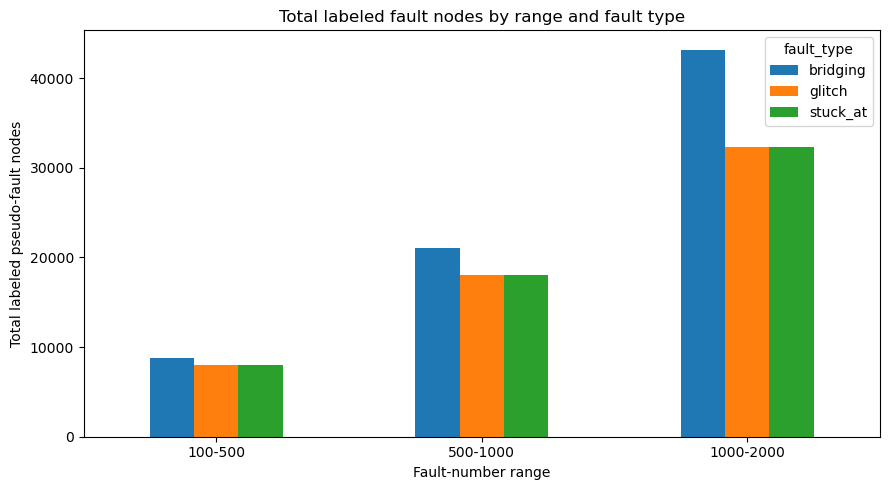

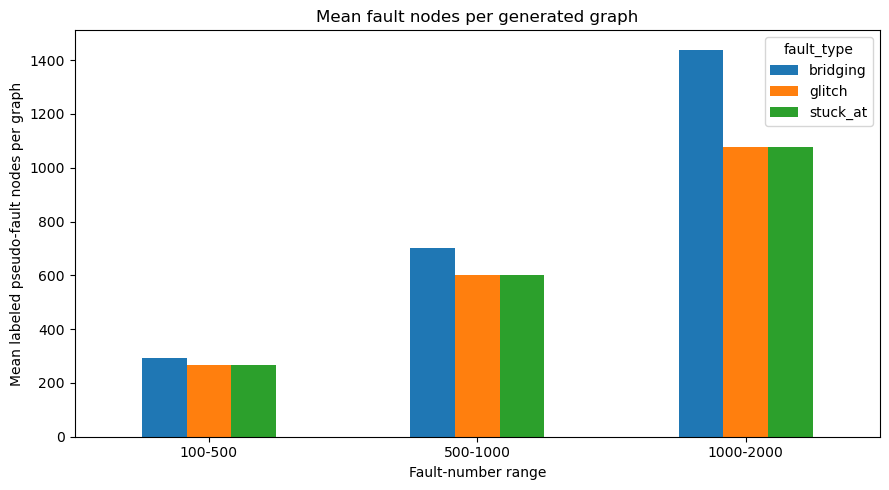

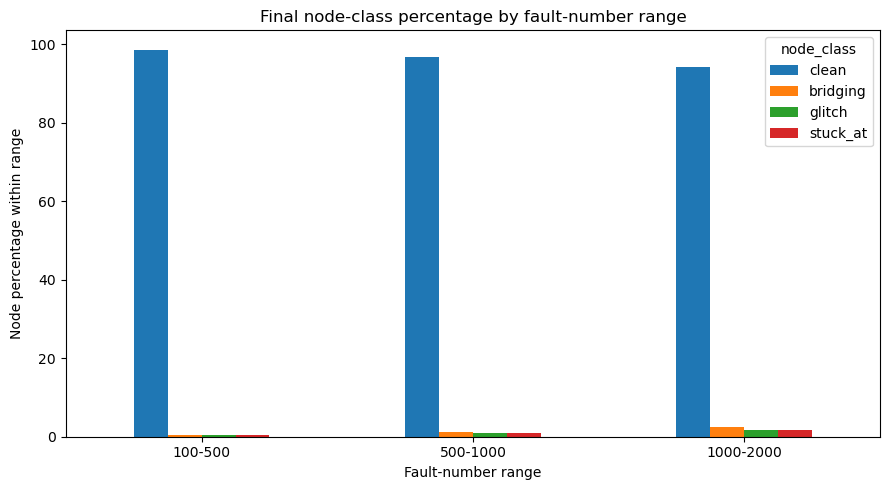

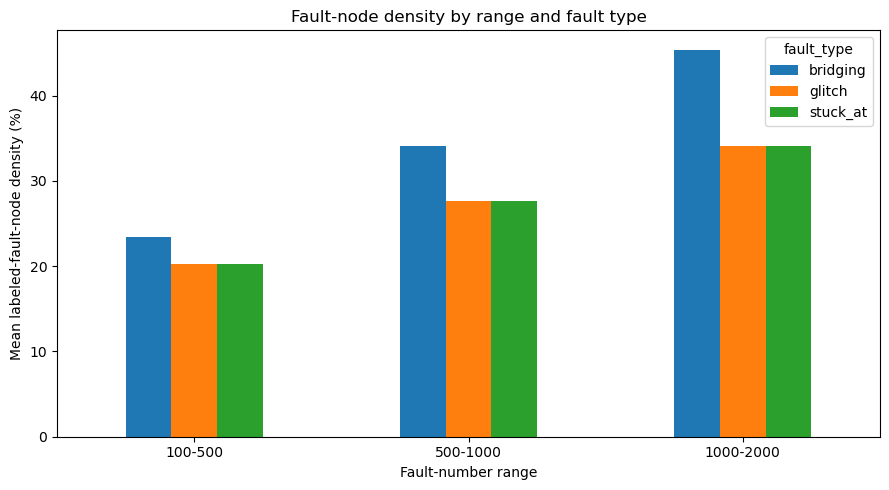


Reviewer-facing summary files written to:
  fault_injection_fig_faultsweep/faultnumber_statistics/fault_node_growth_factors.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/feature_summary_by_range_and_class.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/per_graph_class_counts.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/per_graph_fault_counts.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/per_graph_fault_counts_vs_requested.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/range_class_balance_summary.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/range_faulttype_graph_summary.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/range_node_class_counts.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/range_node_class_percentages.csv
  fault_injection_fig_faultsweep/faultnumber_statistics/range_topology_summary.csv

Reviewer-facing plots written to:
  fault_injection_fig_faultsweep/faultnumber_

In [5]:
# ============================================================
# faultnumber_dataset_statistics.py
#
# Statistics for the fault-number-sweep enhanced graph CSVs.
#
# Reads:
#   fault_injection_fig_faultsweep/enhanced_graph_csv_by_faultnumber/
#       nodes_enhanced_faultnumber_100_500.csv
#       edges_enhanced_faultnumber_100_500.csv
#       nodes_enhanced_faultnumber_500_1000.csv
#       edges_enhanced_faultnumber_500_1000.csv
#       nodes_enhanced_faultnumber_1000_2000.csv
#       edges_enhanced_faultnumber_1000_2000.csv
#
# Writes:
#   fault_injection_fig_faultsweep/faultnumber_statistics/
#       range_node_class_counts.csv
#       range_node_class_percentages.csv
#       range_class_balance_summary.csv
#       range_faulttype_graph_summary.csv
#       range_topology_summary.csv
#       per_graph_class_counts.csv
#       per_graph_fault_counts.csv
#       feature_summary_by_range_and_class.csv
#       per_graph_fault_counts_vs_requested.csv       # if fault_injection_summary.csv exists
#       *.png plots
#
# Purpose:
#   Quantify how 100-500, 500-1000, and 1000-2000 injected-fault ranges
#   change class composition, fault-node counts, topology size, and feature
#   distributions.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import re
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------
# Paths
# -------------------------
FAULT_SWEEP_ROOT = Path("fault_injection_fig_faultsweep")

ENHANCED_DIR = FAULT_SWEEP_ROOT / "enhanced_graph_csv_by_faultnumber"
STATS_DIR = FAULT_SWEEP_ROOT / "faultnumber_statistics"

FAULT_INJECTION_SUMMARY = FAULT_SWEEP_ROOT / "fault_injection_summary.csv"

OVERWRITE_STATS_DIR = True

EXPECTED_RANGES = [
    "100-500",
    "500-1000",
    "1000-2000",
]

FAULT_CLASS_ORDER = [
    "clean",
    "bridging",
    "glitch",
    "stuck_at",
]

FAULT_TYPE_ORDER = [
    "clean",
    "bridging",
    "glitch",
    "stuck_at",
]


# ============================================================
# 2. Helper functions
# ============================================================

def safe_range_label(label: str) -> str:
    return str(label).replace("-", "_").replace(" ", "_")


def pretty_range_label(safe_label: str) -> str:
    return str(safe_label).replace("_", "-")


def parse_range_label(label: str):
    m = re.match(r"^\s*(\d+)\s*[-_]\s*(\d+)\s*$", str(label))

    if not m:
        return np.nan, np.nan

    return int(m.group(1)), int(m.group(2))


def range_sort_key(label: str):
    lo, hi = parse_range_label(label)

    if pd.isna(lo) or pd.isna(hi):
        return (10**12, 10**12, str(label))

    return (int(lo), int(hi), str(label))


def normalize_source_file_name(name: str) -> str:
    """
    Normalize netlist filenames so metadata rows can be matched to graph rows.

    Handles names such as:
      c17.v
      stuck_at_k321_c17.v
      glitch_k900_c432.v
      bridging_k1200_my_netlist.v
      k321_c17.v
    """
    base = Path(str(name)).name

    base = re.sub(r"^(stuck_at|glitch|bridging)_", "", base)
    base = re.sub(r"^k\d+_", "", base)

    return base


def node_file_for_range(range_label: str) -> Path:
    safe = safe_range_label(range_label)
    return ENHANCED_DIR / f"nodes_enhanced_faultnumber_{safe}.csv"


def edge_file_for_range(range_label: str) -> Path:
    safe = safe_range_label(range_label)

    preferred = ENHANCED_DIR / f"edges_enhanced_faultnumber_{safe}.csv"
    typo_fallback = ENHANCED_DIR / f"edges_enhanced_faultnumer_{safe}.csv"

    if preferred.exists():
        return preferred

    if typo_fallback.exists():
        return typo_fallback

    return preferred


def discover_ranges() -> list:
    ranges = []

    for r in EXPECTED_RANGES:
        if node_file_for_range(r).exists():
            ranges.append(r)

    for p in sorted(ENHANCED_DIR.glob("nodes_enhanced_faultnumber_*.csv")):
        safe = p.stem.replace("nodes_enhanced_faultnumber_", "")
        label = pretty_range_label(safe)

        if label not in ranges:
            ranges.append(label)

    return sorted(ranges, key=range_sort_key)


def make_node_class(row):
    """
    Training-time interpretation:
      - label=1 inside a non-clean fault graph is the pseudo fault node.
      - all other nodes are clean.
    """
    if str(row["fault_type"]) != "clean" and int(row["label"]) == 1:
        return str(row["fault_type"])

    return "clean"


def display_df(title: str, df: pd.DataFrame, max_rows: int = 30):
    print("\n" + title)
    print("=" * len(title))

    try:
        from IPython.display import display
        display(df.head(max_rows))
    except Exception:
        print(df.head(max_rows).to_string(index=False))


def ensure_numeric(df: pd.DataFrame, cols: list):
    for c in cols:
        if c in df.columns:
            df[c] = (
                pd.to_numeric(df[c], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0)
            )

    return df


# ============================================================
# 3. Load all enhanced CSVs
# ============================================================

if not ENHANCED_DIR.exists():
    raise FileNotFoundError(
        f"Enhanced folder not found: {ENHANCED_DIR}. "
        "Run the enhanced fault-number feature-engineering script first."
    )

if STATS_DIR.exists():
    if OVERWRITE_STATS_DIR:
        shutil.rmtree(STATS_DIR)
    else:
        raise FileExistsError(
            f"{STATS_DIR} already exists. Set OVERWRITE_STATS_DIR=True to regenerate."
        )

STATS_DIR.mkdir(parents=True, exist_ok=True)

ranges = discover_ranges()

if not ranges:
    raise FileNotFoundError(
        f"No nodes_enhanced_faultnumber_*.csv files found in {ENHANCED_DIR}"
    )

nodes_frames = []
edges_frames = []

for range_label in ranges:
    nfile = node_file_for_range(range_label)
    efile = edge_file_for_range(range_label)

    if not nfile.exists():
        raise FileNotFoundError(f"Missing nodes file for range {range_label}: {nfile}")

    if not efile.exists():
        raise FileNotFoundError(f"Missing edges file for range {range_label}: {efile}")

    lo, hi = parse_range_label(range_label)

    nodes = pd.read_csv(nfile)
    edges = pd.read_csv(efile)

    required_node_cols = [
        "netlist_file",
        "fault_type",
        "node_id",
        "gate_type",
        "label",
    ]

    required_edge_cols = [
        "netlist_file",
        "fault_type",
        "src_node",
        "dst_node",
        "fan_out",
    ]

    for c in required_node_cols:
        if c not in nodes.columns:
            raise ValueError(f"Missing node column {c} in {nfile}")

    for c in required_edge_cols:
        if c not in edges.columns:
            raise ValueError(f"Missing edge column {c} in {efile}")

    nodes["range_label"] = range_label
    nodes["range_min"] = lo
    nodes["range_max"] = hi
    nodes["netlist_file"] = nodes["netlist_file"].astype(str)
    nodes["netlist_file_norm"] = nodes["netlist_file"].map(normalize_source_file_name)
    nodes["fault_type"] = nodes["fault_type"].astype(str)
    nodes["label"] = (
        pd.to_numeric(nodes["label"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
    nodes["node_class"] = nodes.apply(make_node_class, axis=1)

    edges["range_label"] = range_label
    edges["range_min"] = lo
    edges["range_max"] = hi
    edges["netlist_file"] = edges["netlist_file"].astype(str)
    edges["netlist_file_norm"] = edges["netlist_file"].map(normalize_source_file_name)
    edges["fault_type"] = edges["fault_type"].astype(str)
    edges["fan_out"] = (
        pd.to_numeric(edges["fan_out"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    nodes_frames.append(nodes)
    edges_frames.append(edges)

nodes_all = pd.concat(nodes_frames, ignore_index=True)
edges_all = pd.concat(edges_frames, ignore_index=True)

numeric_feature_cols = [
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout",
    "fanout_norm",
    "gate_delay",
]

nodes_all = ensure_numeric(nodes_all, numeric_feature_cols)

print("Loaded enhanced fault-number-sweep data:")
print(f"  ranges: {ranges}")
print(f"  total node rows: {len(nodes_all):,}")
print(f"  total edge rows: {len(edges_all):,}")


# ============================================================
# 4. Class-level node counts by fault-number range
# ============================================================

class_counts = (
    nodes_all
    .groupby(["range_label", "range_min", "range_max", "node_class"], as_index=False)
    .size()
    .rename(columns={"size": "node_count"})
)

range_totals = (
    nodes_all
    .groupby(["range_label"], as_index=False)
    .size()
    .rename(columns={"size": "range_total_nodes"})
)

class_counts = class_counts.merge(range_totals, on="range_label", how="left")
class_counts["node_percent_within_range"] = (
    100.0 * class_counts["node_count"] / class_counts["range_total_nodes"].clip(lower=1)
)

# Ordered pivot tables.
available_classes = list(nodes_all["node_class"].dropna().unique())
class_order = [c for c in FAULT_CLASS_ORDER if c in available_classes]
class_order += sorted([c for c in available_classes if c not in class_order])

range_order = sorted(ranges, key=range_sort_key)

class_count_pivot = (
    class_counts
    .pivot_table(
        index="range_label",
        columns="node_class",
        values="node_count",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(index=range_order)
    .reindex(columns=class_order, fill_value=0)
)

class_percent_pivot = (
    class_counts
    .pivot_table(
        index="range_label",
        columns="node_class",
        values="node_percent_within_range",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(index=range_order)
    .reindex(columns=class_order, fill_value=0)
)

class_count_pivot.to_csv(STATS_DIR / "range_node_class_counts.csv")
class_percent_pivot.to_csv(STATS_DIR / "range_node_class_percentages.csv")

display_df(
    "Node counts per final node class and fault-number range",
    class_count_pivot.reset_index(),
)

display_df(
    "Node percentages per final node class and fault-number range",
    class_percent_pivot.reset_index(),
)


# ============================================================
# 5. Class-balance summary
# ============================================================

class_balance = class_count_pivot.copy()

for c in class_order:
    if c not in class_balance.columns:
        class_balance[c] = 0

fault_classes = [c for c in class_order if c != "clean"]

class_balance["total_nodes"] = class_balance[class_order].sum(axis=1)
class_balance["total_fault_nodes"] = class_balance[fault_classes].sum(axis=1) if fault_classes else 0
class_balance["fault_node_percent"] = (
    100.0 * class_balance["total_fault_nodes"] / class_balance["total_nodes"].clip(lower=1)
)

if "clean" in class_balance.columns:
    class_balance["clean_to_fault_ratio"] = (
        class_balance["clean"] / class_balance["total_fault_nodes"].replace(0, np.nan)
    )
else:
    class_balance["clean_to_fault_ratio"] = np.nan

class_balance = class_balance.reset_index()
class_balance.to_csv(STATS_DIR / "range_class_balance_summary.csv", index=False)

display_df(
    "Class-balance summary by fault-number range",
    class_balance,
)


# ============================================================
# 6. Per-graph graph-size and fault-node statistics
# ============================================================

node_graph_group_cols = [
    "range_label",
    "range_min",
    "range_max",
    "netlist_file",
    "netlist_file_norm",
    "fault_type",
]

graph_node_stats = (
    nodes_all
    .groupby(node_graph_group_cols, as_index=False)
    .agg(
        nodes=("node_id", "count"),
        labeled_fault_nodes=("label", "sum"),
        final_clean_nodes=("node_class", lambda s: int((s == "clean").sum())),
        final_bridging_nodes=("node_class", lambda s: int((s == "bridging").sum())),
        final_glitch_nodes=("node_class", lambda s: int((s == "glitch").sum())),
        final_stuck_at_nodes=("node_class", lambda s: int((s == "stuck_at").sum())),
        mean_path_depth=("path_depth", "mean"),
        max_path_depth=("path_depth", "max"),
        mean_dist_to_PO=("dist_to_PO", "mean"),
        max_dist_to_PO=("dist_to_PO", "max"),
        mean_fanout=("fanout", "mean"),
        max_fanout=("fanout", "max"),
        mean_CC0_exact=("CC0_exact", "mean"),
        mean_CC1_exact=("CC1_exact", "mean"),
        mean_CO_exact=("CO_exact", "mean"),
    )
)

edge_graph_group_cols = [
    "range_label",
    "netlist_file",
    "netlist_file_norm",
    "fault_type",
]

graph_edge_stats = (
    edges_all
    .groupby(edge_graph_group_cols, as_index=False)
    .agg(
        edges=("src_node", "count"),
        mean_edge_fan_out=("fan_out", "mean"),
        max_edge_fan_out=("fan_out", "max"),
    )
)

graph_stats = graph_node_stats.merge(
    graph_edge_stats,
    on=edge_graph_group_cols,
    how="left",
)

graph_stats["edges"] = graph_stats["edges"].fillna(0).astype(int)
graph_stats["mean_edge_fan_out"] = graph_stats["mean_edge_fan_out"].fillna(0)
graph_stats["max_edge_fan_out"] = graph_stats["max_edge_fan_out"].fillna(0)
graph_stats["fault_node_density_percent"] = (
    100.0 * graph_stats["labeled_fault_nodes"] / graph_stats["nodes"].clip(lower=1)
)

graph_stats.to_csv(STATS_DIR / "per_graph_fault_counts.csv", index=False)

display_df(
    "Per-graph fault-node count examples",
    graph_stats[
        [
            "range_label",
            "netlist_file_norm",
            "fault_type",
            "nodes",
            "edges",
            "labeled_fault_nodes",
            "fault_node_density_percent",
        ]
    ],
    max_rows=20,
)


# ============================================================
# 7. Summary by range and fault type
# ============================================================

available_fault_types = list(graph_stats["fault_type"].dropna().unique())
fault_type_order = [f for f in FAULT_TYPE_ORDER if f in available_fault_types]
fault_type_order += sorted([f for f in available_fault_types if f not in fault_type_order])

range_faulttype_summary = (
    graph_stats
    .groupby(["range_label", "range_min", "range_max", "fault_type"], as_index=False)
    .agg(
        graph_count=("netlist_file_norm", "count"),
        unique_netlists=("netlist_file_norm", "nunique"),
        total_nodes=("nodes", "sum"),
        total_edges=("edges", "sum"),
        total_labeled_fault_nodes=("labeled_fault_nodes", "sum"),
        mean_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "mean"),
        median_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "median"),
        min_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "min"),
        max_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "max"),
        std_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "std"),
        mean_fault_node_density_percent=("fault_node_density_percent", "mean"),
        median_fault_node_density_percent=("fault_node_density_percent", "median"),
        mean_nodes_per_graph=("nodes", "mean"),
        mean_edges_per_graph=("edges", "mean"),
        mean_path_depth=("mean_path_depth", "mean"),
        max_path_depth=("max_path_depth", "max"),
        mean_dist_to_PO=("mean_dist_to_PO", "mean"),
        max_dist_to_PO=("max_dist_to_PO", "max"),
        mean_fanout=("mean_fanout", "mean"),
        max_fanout=("max_fanout", "max"),
    )
)

range_faulttype_summary["std_labeled_fault_nodes_per_graph"] = (
    range_faulttype_summary["std_labeled_fault_nodes_per_graph"].fillna(0)
)

range_faulttype_summary = (
    range_faulttype_summary
    .sort_values(
        by=["range_min", "range_max", "fault_type"],
        key=lambda s: s.map(lambda x: fault_type_order.index(x) if x in fault_type_order else 999)
        if s.name == "fault_type" else s,
    )
    .reset_index(drop=True)
)

range_faulttype_summary.to_csv(STATS_DIR / "range_faulttype_graph_summary.csv", index=False)

display_df(
    "Range and fault-type graph summary",
    range_faulttype_summary,
)


# ============================================================
# 8. Overall topology summary by range
# ============================================================

range_topology_summary = (
    graph_stats
    .groupby(["range_label", "range_min", "range_max"], as_index=False)
    .agg(
        graph_count=("netlist_file_norm", "count"),
        unique_netlists=("netlist_file_norm", "nunique"),
        total_nodes=("nodes", "sum"),
        total_edges=("edges", "sum"),
        total_labeled_fault_nodes=("labeled_fault_nodes", "sum"),
        mean_nodes_per_graph=("nodes", "mean"),
        median_nodes_per_graph=("nodes", "median"),
        mean_edges_per_graph=("edges", "mean"),
        median_edges_per_graph=("edges", "median"),
        mean_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "mean"),
        median_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "median"),
        max_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "max"),
        mean_fault_node_density_percent=("fault_node_density_percent", "mean"),
        mean_path_depth=("mean_path_depth", "mean"),
        max_path_depth=("max_path_depth", "max"),
        mean_dist_to_PO=("mean_dist_to_PO", "mean"),
        max_dist_to_PO=("max_dist_to_PO", "max"),
        max_fanout=("max_fanout", "max"),
    )
)

range_topology_summary = (
    range_topology_summary
    .sort_values(["range_min", "range_max"])
    .reset_index(drop=True)
)

range_topology_summary.to_csv(STATS_DIR / "range_topology_summary.csv", index=False)

display_df(
    "Overall topology summary by fault-number range",
    range_topology_summary,
)


# ============================================================
# 9. Per-graph final class count matrix
# ============================================================

per_graph_class_counts = (
    nodes_all
    .groupby(
        [
            "range_label",
            "range_min",
            "range_max",
            "netlist_file",
            "netlist_file_norm",
            "fault_type",
            "node_class",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "node_count"})
)

per_graph_class_counts_pivot = (
    per_graph_class_counts
    .pivot_table(
        index=[
            "range_label",
            "range_min",
            "range_max",
            "netlist_file",
            "netlist_file_norm",
            "fault_type",
        ],
        columns="node_class",
        values="node_count",
        fill_value=0,
        aggfunc="sum",
    )
    .reset_index()
)

for c in class_order:
    if c not in per_graph_class_counts_pivot.columns:
        per_graph_class_counts_pivot[c] = 0

per_graph_class_counts_pivot["total_nodes"] = per_graph_class_counts_pivot[class_order].sum(axis=1)

per_graph_class_counts_pivot.to_csv(STATS_DIR / "per_graph_class_counts.csv", index=False)

display_df(
    "Per-graph class-count matrix examples",
    per_graph_class_counts_pivot,
    max_rows=20,
)


# ============================================================
# 10. Feature summaries by range and final node class
# ============================================================

feature_summary = (
    nodes_all
    .groupby(["range_label", "range_min", "range_max", "node_class"])[numeric_feature_cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

feature_summary.columns = [
    f"{feature}_{stat}"
    for feature, stat in feature_summary.columns
]

feature_summary = (
    feature_summary
    .reset_index()
    .sort_values(["range_min", "range_max", "node_class"])
    .reset_index(drop=True)
)

feature_summary.to_csv(STATS_DIR / "feature_summary_by_range_and_class.csv", index=False)

display_df(
    "Enhanced feature summary by range and final node class",
    feature_summary,
    max_rows=20,
)


# ============================================================
# 11. Optional cross-check against fault injection metadata
# ============================================================

if FAULT_INJECTION_SUMMARY.exists():
    fault_summary = pd.read_csv(FAULT_INJECTION_SUMMARY)

    required_summary_cols = [
        "range_label",
        "source_file",
        "fault_type",
        "requested_k",
        "effective_k",
    ]

    missing_summary_cols = [
        c for c in required_summary_cols
        if c not in fault_summary.columns
    ]

    if missing_summary_cols:
        warnings.warn(
            f"Cannot perform metadata cross-check. Missing columns in "
            f"{FAULT_INJECTION_SUMMARY}: {missing_summary_cols}"
        )
    else:
        fault_summary["netlist_file_norm"] = fault_summary["source_file"].map(normalize_source_file_name)
        fault_summary["range_label"] = fault_summary["range_label"].astype(str)
        fault_summary["fault_type"] = fault_summary["fault_type"].astype(str)

        meta_cols_to_keep = [
            "range_label",
            "netlist_file_norm",
            "source_file",
            "fault_type",
            "requested_k",
            "effective_k",
        ]

        for optional_col in [
            "candidate_nets",
            "feasible_fault_sites",
            "capped",
            "output_file",
        ]:
            if optional_col in fault_summary.columns:
                meta_cols_to_keep.append(optional_col)

        graph_fault_only = graph_stats[graph_stats["fault_type"] != "clean"].copy()

        fault_crosscheck = graph_fault_only.merge(
            fault_summary[meta_cols_to_keep],
            on=["range_label", "netlist_file_norm", "fault_type"],
            how="left",
        )

        fault_crosscheck["effective_k"] = pd.to_numeric(
            fault_crosscheck["effective_k"],
            errors="coerce",
        )

        fault_crosscheck["fault_nodes_minus_effective_k"] = (
            fault_crosscheck["labeled_fault_nodes"] - fault_crosscheck["effective_k"]
        )

        fault_crosscheck["metadata_matched"] = fault_crosscheck["effective_k"].notna().astype(int)

        fault_crosscheck.to_csv(
            STATS_DIR / "per_graph_fault_counts_vs_requested.csv",
            index=False,
        )

        matched = int(fault_crosscheck["metadata_matched"].sum())
        total = int(len(fault_crosscheck))

        print("\nMetadata cross-check against fault_injection_summary.csv")
        print("=======================================================")
        print(f"Matched graph rows: {matched:,} / {total:,}")

        if matched > 0:
            display_df(
                "Fault-node count versus requested/effective injected faults",
                fault_crosscheck[
                    [
                        "range_label",
                        "source_file",
                        "fault_type",
                        "requested_k",
                        "effective_k",
                        "labeled_fault_nodes",
                        "fault_nodes_minus_effective_k",
                        "candidate_nets" if "candidate_nets" in fault_crosscheck.columns else "metadata_matched",
                        "feasible_fault_sites" if "feasible_fault_sites" in fault_crosscheck.columns else "metadata_matched",
                        "capped" if "capped" in fault_crosscheck.columns else "metadata_matched",
                    ]
                ],
                max_rows=20,
            )

            mismatch_rows = fault_crosscheck[
                (fault_crosscheck["metadata_matched"] == 1) &
                (fault_crosscheck["fault_nodes_minus_effective_k"] != 0)
            ]

            print(f"Rows where labeled fault nodes != effective_k: {len(mismatch_rows):,}")

else:
    print(
        f"\nNo {FAULT_INJECTION_SUMMARY} found. "
        "Skipping requested_k/effective_k metadata cross-check."
    )


# ============================================================
# 12. Growth-factor statistics
# ============================================================

fault_only_summary = range_faulttype_summary[
    range_faulttype_summary["fault_type"] != "clean"
].copy()

fault_totals_pivot = (
    fault_only_summary
    .pivot_table(
        index="range_label",
        columns="fault_type",
        values="total_labeled_fault_nodes",
        fill_value=0,
        aggfunc="sum",
    )
    .reindex(index=range_order)
)

fault_mean_per_graph_pivot = (
    fault_only_summary
    .pivot_table(
        index="range_label",
        columns="fault_type",
        values="mean_labeled_fault_nodes_per_graph",
        fill_value=0,
        aggfunc="mean",
    )
    .reindex(index=range_order)
)

growth_rows = []

if len(range_order) >= 2:
    first_range = range_order[0]
    last_range = range_order[-1]

    for ft in [c for c in fault_type_order if c != "clean"]:
        if ft not in fault_totals_pivot.columns:
            continue

        first_total = float(fault_totals_pivot.loc[first_range, ft])
        last_total = float(fault_totals_pivot.loc[last_range, ft])

        first_mean = float(fault_mean_per_graph_pivot.loc[first_range, ft])
        last_mean = float(fault_mean_per_graph_pivot.loc[last_range, ft])

        growth_rows.append({
            "fault_type": ft,
            "first_range": first_range,
            "last_range": last_range,
            "total_fault_nodes_first_range": first_total,
            "total_fault_nodes_last_range": last_total,
            "total_fault_nodes_growth_factor": last_total / first_total if first_total > 0 else np.nan,
            "mean_fault_nodes_per_graph_first_range": first_mean,
            "mean_fault_nodes_per_graph_last_range": last_mean,
            "mean_fault_nodes_per_graph_growth_factor": last_mean / first_mean if first_mean > 0 else np.nan,
        })

growth_summary = pd.DataFrame(growth_rows)
growth_summary.to_csv(STATS_DIR / "fault_node_growth_factors.csv", index=False)

display_df(
    "Fault-node growth from lowest to highest fault-number range",
    growth_summary,
)


# ============================================================
# 13. Plots
# ============================================================

plt.figure(figsize=(9, 5))
fault_totals_pivot.plot(kind="bar", ax=plt.gca())
plt.xlabel("Fault-number range")
plt.ylabel("Total labeled pseudo-fault nodes")
plt.title("Total labeled fault nodes by range and fault type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(STATS_DIR / "total_labeled_fault_nodes_by_range.png", dpi=200)
plt.show()


plt.figure(figsize=(9, 5))
fault_mean_per_graph_pivot.plot(kind="bar", ax=plt.gca())
plt.xlabel("Fault-number range")
plt.ylabel("Mean labeled pseudo-fault nodes per graph")
plt.title("Mean fault nodes per generated graph")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(STATS_DIR / "mean_fault_nodes_per_graph_by_range.png", dpi=200)
plt.show()


plt.figure(figsize=(9, 5))
class_percent_pivot.plot(kind="bar", ax=plt.gca())
plt.xlabel("Fault-number range")
plt.ylabel("Node percentage within range")
plt.title("Final node-class percentage by fault-number range")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(STATS_DIR / "node_class_percentages_by_range.png", dpi=200)
plt.show()


plt.figure(figsize=(9, 5))
density_pivot = (
    fault_only_summary
    .pivot_table(
        index="range_label",
        columns="fault_type",
        values="mean_fault_node_density_percent",
        fill_value=0,
        aggfunc="mean",
    )
    .reindex(index=range_order)
)
density_pivot.plot(kind="bar", ax=plt.gca())
plt.xlabel("Fault-number range")
plt.ylabel("Mean labeled-fault-node density (%)")
plt.title("Fault-node density by range and fault type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(STATS_DIR / "fault_node_density_by_range.png", dpi=200)
plt.show()


# ============================================================
# 14. Compact reviewer-facing printout
# ============================================================

print("\nReviewer-facing summary files written to:")
print("========================================")
for p in sorted(STATS_DIR.glob("*.csv")):
    print(" ", p)

print("\nReviewer-facing plots written to:")
print("================================")
for p in sorted(STATS_DIR.glob("*.png")):
    print(" ", p)

print("\nCompact key tables:")
print("===================")

print("\n1) Node counts per class:")
print(class_count_pivot.to_string())

print("\n2) Class balance:")
print(class_balance.to_string(index=False))

print("\n3) Fault-type summary:")
print(
    range_faulttype_summary[
        [
            "range_label",
            "fault_type",
            "graph_count",
            "total_labeled_fault_nodes",
            "mean_labeled_fault_nodes_per_graph",
            "min_labeled_fault_nodes_per_graph",
            "max_labeled_fault_nodes_per_graph",
            "mean_fault_node_density_percent",
        ]
    ].to_string(index=False)
)

print("\nStatistics generation complete.")